In [1]:
# Antes de correr este archivo, renombrar los videos usando "Rename czi files.ipynb"

# Importo librerías necesarias
from ipynb.fs.defs.aux_functions import *

from ipywidgets import interact, interact_manual, interactive, fixed
from IPython.display import display
import pandas as pd

from os.path import exists
from PIL import Image

c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\tensorflow\python\framework\dtypes.

In [2]:
#Cargamos la data de los animales
areas_dir = r'D:\Analisis conf\Areas 2026'

areas = load_areas(areas_dir)

for key in areas:
    print(key + ":", len(areas[key].trials), "trials.")

148-1: 14 trials.
149-1: 14 trials.
150-1: 14 trials.
151-1: 14 trials.
154-1: 14 trials.
156-1: 14 trials.
157-1: 14 trials.
159-1: 14 trials.
162-1: 14 trials.
164-1: 14 trials.
165-1: 14 trials.
166-1: 14 trials.
170-1: 14 trials.
171-1: 14 trials.
172-1: 14 trials.
176-1: 14 trials.
177-1: 14 trials.
181-1: 14 trials.
183-1: 14 trials.
184-1: 14 trials.
185-1: 14 trials.
190-1: 14 trials.
191-1: 14 trials.
192-1: 14 trials.
193-1: 14 trials.


In [3]:
#Levantamos metadata del exel del experimento
dataset_2 = pd.read_excel(r"C:\Users\PC\Documents\GitHub\social_isolation_habenula_imaging\Exp_26/HabenulaPosta_2026.xlsx")

In [4]:
#Metemos la metadata en las areas
for key in areas:
    areas[key].edad = areas[key].trials[0].data['Edad']
    areas[key].n_un_hb = len(areas[key].trials[0].roi_activities['Hb'])
    areas[key].aislado = list(dataset_2['aislado'][dataset_2['animal']==int(key[:-2])])[0]

In [5]:
# import numpy as np
from scipy.signal import savgol_filter, medfilt
from scipy.ndimage import percentile_filter
# import matplotlib.pyplot as plt
from pykalman import KalmanFilter
import pywt
# from filterpy.kalman import KalmanFilter


def kalman_denoise(data):
    # Initialize the Kalman filter
    kf = KalmanFilter(transition_matrices = [1],
                      observation_matrices = [1],
                      initial_state_mean = data[0],
                      initial_state_covariance = 1,
                      observation_covariance=0.1,
                      transition_covariance=0.1)
    
    # Use the Kalman filter to estimate the hidden state
    return kf.smooth(data)[0].flatten()

def past_percentile_filter(data, percentile, size):
    output = np.empty_like(data)
    for i in range(len(data)):
        if i < size:
            # For the initial elements, we still need to consider some "future" elements
            output[i] = np.percentile(data[:i+size+1], percentile)
        else:
            output[i] = np.percentile(data[i-size:i+1], percentile)
    return output

# def to_dffs(activities, baseline_window=60, percentile=8): 2026
def to_dffs(activities, baseline_window=20, percentile=8):
    # Calculate a rolling baseline using a percentile filter
    baselines = np.empty_like(activities)
    for i in range(activities.shape[0]):
        #baselines[i, :] = percentile_filter(activities[i, :], percentile, size=baseline_window)
        baselines[i, :] = past_percentile_filter(activities[i, :], percentile, size=baseline_window)

    # Ensure the baseline is not zero to avoid division by zero
    baselines = np.where(baselines==0, np.finfo(float).eps, baselines)

    # Calculate dF/F
    dffs = (activities - baselines) / baselines

    return dffs, baselines

def to_binaries(dffs, smooth_window=5, polyorder=3, multiplier=3):
    # Smooth the dF/F signal using a Savitzky-Golay filter
    smooth_dffs = np.empty_like(dffs)
    
    for i in range(dffs.shape[0]):
    #    smooth_dffs[i, :] = savgol_filter(dffs[i, :], smooth_window, polyorder)
        smooth_dffs[i, :] = kalman_denoise(dffs[i, :])
    #    smooth_dffs[i, :] = wavelet_denoise(dffs[i, :])
        
    # Calculate the noise level using the median absolute deviation
    mad = np.median(np.abs(smooth_dffs - np.median(smooth_dffs, axis=1, keepdims=True)), axis=1, keepdims=True)

    # Threshold for event detection
    threshold = np.median(smooth_dffs, axis=1, keepdims=True) + multiplier * mad

    # A neuron is active if the dF/F signal exceeds the threshold
    binaries = smooth_dffs > threshold

    return binaries, smooth_dffs

In [6]:
import dask.bag as db

# Adjust these values based on your system's resources
num_workers = 10 # Set the number of workers
client = Client(n_workers=num_workers)

def process_trial(trial):
    print("Processing trial number", trial.trial)

    trial.roi_dffs_rea = {}
    trial.roi_baselines_rea = {}
    trial.roi_binaries_rea = {}
    trial.roi_smooth_dffs_rea = {}
    
    for subarea in trial.roi_activities:
        activities = trial.roi_activities[subarea]

        if activities.shape[0] == 0:
            print("No neurons in this region... weird.", trial.trial, subarea)
            continue

        trial.roi_dffs_rea[subarea], trial.roi_baselines_rea[subarea] = to_dffs(activities, baseline_window=60)
        trial.roi_binaries_rea[subarea], trial.roi_smooth_dffs_rea[subarea] = to_binaries(trial.roi_dffs[subarea])

        print(subarea, "| Activities:", activities.shape, "| dF/Fs:", trial.roi_dffs[subarea].shape, "| Binaries:", trial.roi_binaries[subarea].shape)
    
    # trial.grid_dffs = {}
    # trial.grid_baselines = {}
    # trial.grid_binaries = {}
    # trial.grid_smooth_dffs = {}
    
    # for subarea in trial.grid_activities:
    #     activities = trial.grid_activities[subarea]

    #     if activities.shape[0] == 0:
    #         print("No neurons in this region... weird.", trial.trial, subarea)
    #         continue

    #     trial.grid_dffs[subarea], trial.grid_baselines[subarea] = to_dffs(activities)
    #     trial.grid_binaries[subarea], trial.grid_smooth_dffs[subarea] = to_binaries(trial.grid_dffs[subarea])

    #     print(subarea, "| Activities:", activities.shape, "| dF/Fs:", trial.grid_dffs[subarea].shape, "| Binaries:", trial.grid_binaries[subarea].shape)

    return trial

for key in areas:
    # if '52' not in key and key[0] in ['7', '8']:
    if '52' not in key :
        print("Processing area number", key)
        
        trials_bag = db.from_sequence(areas[key].trials)
        trials = trials_bag.map(process_trial).compute()
        
        # Now, trials contain the processed trial objects and you can assign it back or use as needed.
        areas[key].trials_rea = trials


Processing area number 148-1
Processing area number 149-1
Processing area number 150-1
Processing area number 151-1
Processing area number 154-1
Processing area number 156-1
Processing area number 157-1
Processing area number 159-1
Processing area number 162-1
Processing area number 164-1
Processing area number 165-1
Processing area number 166-1
Processing area number 170-1
Processing area number 171-1
Processing area number 172-1
Processing area number 176-1
Processing area number 177-1
Processing area number 181-1
Processing area number 183-1
Processing area number 184-1
Processing area number 185-1
Processing area number 190-1
Processing area number 191-1
Processing area number 192-1
Processing area number 193-1


# Distribución de edad  

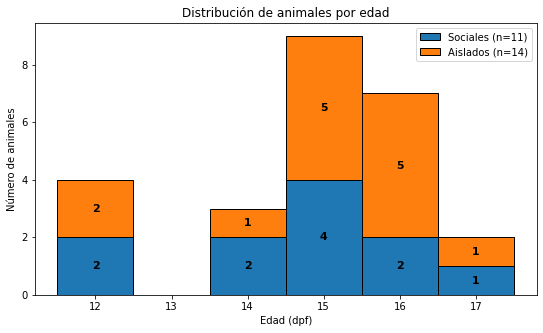

In [25]:
df = pd.DataFrame({
    "edad": [area.edad for area in areas.values()],
    "aislado": [area.aislado for area in areas.values()]
})

bins = np.arange(
    np.floor(df["edad"].min()) - 0.5,
    np.ceil(df["edad"].max()) + 1.5,
    1
)

sociales = df.loc[df["aislado"] == 0, "edad"]
aislados = df.loc[df["aislado"] == 1, "edad"]

n_sociales = len(sociales)
n_aislados = len(aislados)

# Conteos REALES por edad y condición
counts_sociales, _ = np.histogram(sociales, bins=bins)
counts_aislados, _ = np.histogram(aislados, bins=bins)

plt.figure(figsize=(9, 5))

counts, bins, patches = plt.hist(
    [sociales, aislados],
    bins=bins,
    stacked=True,
    label=[
        f"Sociales (n={n_sociales})",
        f"Aislados (n={n_aislados})"
    ],
    edgecolor="black"
)

# Etiquetas de SOCIALES
plt.bar_label(
    patches[0],
    labels=[
        str(n) if n > 0 else ""
        for n in counts_sociales
    ],
    label_type="center",
    fontsize=11,
    fontweight="bold"
)

# Etiquetas de AISLADOS
plt.bar_label(
    patches[1],
    labels=[
        str(n) if n > 0 else ""
        for n in counts_aislados
    ],
    label_type="center",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Edad (dpf)")
plt.ylabel("Número de animales")
plt.title("Distribución de animales por edad")

plt.xticks(
    np.arange(
        np.floor(df["edad"].min()),
        np.ceil(df["edad"].max()) + 1,
        1
    )
)

plt.legend()
plt.show()

# Promedio de prop activa

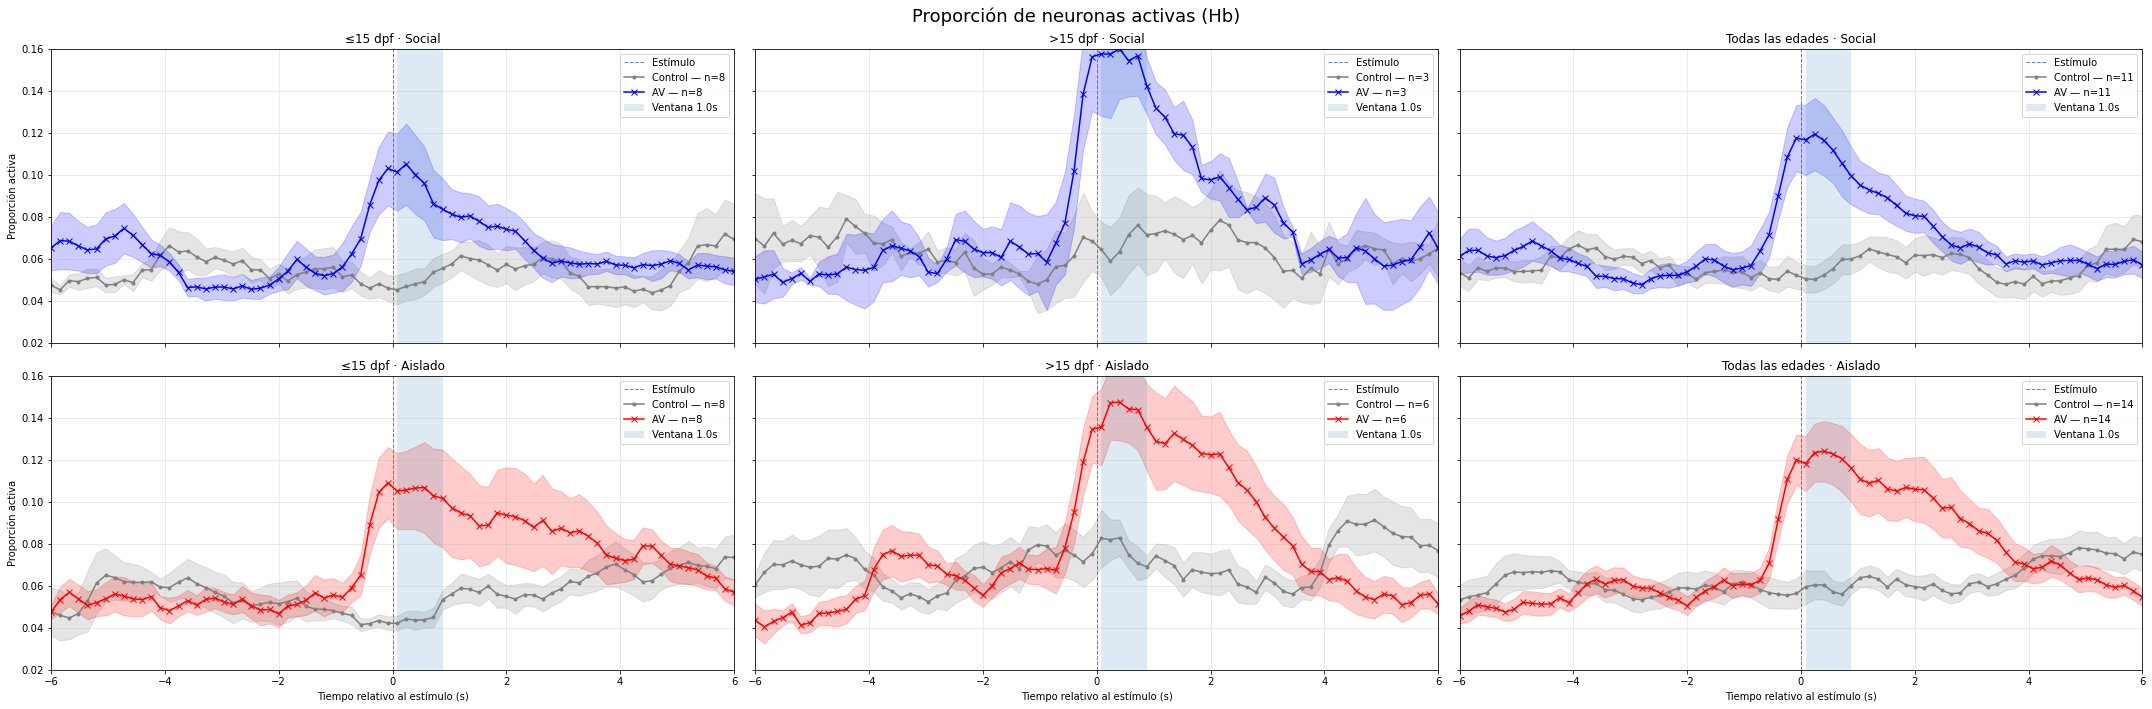

In [ ]:
region_key = 'Hb'
stim_s = 23.6
win_s = 1.0
fps = 6.25

grupos = {
    "≤15 dpf": lambda e: e <= 15,
    ">15 dpf": lambda e: e > 15,
    "Todas las edades": lambda e: True
}

# os.chdir(r'H:\My Drive\Valen Agulló\SAN 2025')

def _get_condition(trial):
    return 'AV' if getattr(trial, 'vis', 0) == 1 and getattr(trial, 'aud', 0) == 1 else 'C'

def _trial_timebase(trial, fallback_fps):
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft, dtype=float)
        fps_est = 1 / np.median(np.diff(ft)) if len(ft) > 1 else fallback_fps
        return ft, fps_est

    t_fps = getattr(trial, 'fps', fallback_fps)
    if t_fps is None:
        raise ValueError("Falta fps.")

    rb = getattr(trial, 'roi_binaries_rea', None)
    if rb is None or region_key not in rb:
        raise ValueError(f"Falta roi_binaries_rea['{region_key}'].")

    n_frames = np.asarray(rb[region_key]).shape[1]
    return np.arange(n_frames) / t_fps, t_fps

def _prop_active_per_frame(trial):
    rb = getattr(trial, 'roi_binaries_rea', None)
    if rb is None or region_key not in rb:
        return None
    return (np.asarray(rb[region_key]) > 0).mean(axis=0)

def _truncate(arrays):
    if not arrays:
        return [], 0
    m = min(map(len, arrays))
    return [a[:m] for a in arrays], m

def _mean_sem(traces):
    X, m = _truncate(traces)
    if m == 0:
        return None, None
    X = np.vstack(X)
    mean = X.mean(axis=0)
    sem = X.std(axis=0, ddof=1) / np.sqrt(len(X)) if len(X) > 1 else np.zeros(m)
    return mean, sem


# resultados[grupo][Social/Aislado][C/AV]
resultados = {
    g: {s: {c: {"animals": [], "t": None} for c in ["C", "AV"]}
        for s in ["Social", "Aislado"]}
    for g in grupos
}

for k, area in areas.items():
    edad = int(getattr(area, 'edad', -999))
    aislado = getattr(area, 'aislado', None)

    if aislado == 0:
        social = "Social"
    elif aislado == 1:
        social = "Aislado"
    else:
        continue

    grupos_animal = [g for g, pred in grupos.items() if pred(edad)]
    per_trial = {"C": [], "AV": []}
    per_time = {"C": [], "AV": []}

    for tr in getattr(area, 'trials_rea', []):
        cond = _get_condition(tr)
        try:
            t, _ = _trial_timebase(tr, fps)
            prop = _prop_active_per_frame(tr)
            if prop is None:
                continue
            m = min(len(t), len(prop))
            per_trial[cond].append(prop[:m])
            per_time[cond].append(t[:m])
        except Exception as e:
            print(f"[WARNING] {k}: {e}")

    for cond in ["C", "AV"]:
        series, m = _truncate(per_trial[cond])
        if m == 0:
            continue

        times, _ = _truncate(per_time[cond])
        animal_mean = np.vstack(series).mean(axis=0)
        t_common = times[0][:m]

        for g in grupos_animal:
            resultados[g][social][cond]["animals"].append(animal_mean)
            if resultados[g][social][cond]["t"] is None:
                resultados[g][social][cond]["t"] = t_common


# =================================================================
# UNA FIGURA: 2 filas × 3 columnas
# =================================================================

fig, axes = plt.subplots(2, 3, figsize=(30, 10), sharex=True, sharey=True)

for col, gname in enumerate(grupos):
    for row, social in enumerate(["Social", "Aislado"]):
        ax = axes[row, col]
        data = resultados[gname][social]

        mean_C, sem_C = _mean_sem(data["C"]["animals"])
        mean_AV, sem_AV = _mean_sem(data["AV"]["animals"])

        ref = data["AV"] if mean_AV is not None else data["C"]
        mean_ref = mean_AV if mean_AV is not None else mean_C

        if mean_ref is None:
            ax.set_title(f"{gname} · {social}\nSin datos")
            continue

        t = ref["t"][:len(mean_ref)] - stim_s
        color_AV = "blue" if social == "Social" else "red"

        # Ventana 1 s post-estímulo
        w = (t >= 0) & (t < win_s)
        if w.any():
            ax.axvspan(t[w][0], t[w][-1], alpha=.15, label=f"Ventana {win_s:.1f}s")

        ax.axvline(0, linestyle="--", linewidth=1, alpha=.8, label="Estímulo")

        if mean_C is not None:
            m = min(len(t), len(mean_C))
            ax.plot(t[:m], mean_C[:m], color="gray", marker=".",
                    label=f"Control — n={len(data['C']['animals'])}")
            if sem_C is not None:
                ax.fill_between(t[:m], mean_C[:m]-sem_C[:m],
                                mean_C[:m]+sem_C[:m], color="gray", alpha=.2)

        if mean_AV is not None:
            m = min(len(t), len(mean_AV))
            ax.plot(t[:m], mean_AV[:m], color=color_AV, marker="x",
                    label=f"AV — n={len(data['AV']['animals'])}")
            if sem_AV is not None:
                ax.fill_between(t[:m], mean_AV[:m]-sem_AV[:m],
                                mean_AV[:m]+sem_AV[:m], color=color_AV, alpha=.2)

        ax.set_title(f"{gname} · {social}")
        ax.set_xlim(-6, 6)
        ax.set_ylim(.02, .16)
        ax.grid(alpha=.3)
        ax.legend()

        if row == 1:
            ax.set_xlabel("Tiempo relativo al estímulo (s)")
        if col == 0:
            ax.set_ylabel("Proporción activa")

fig.suptitle("Proporción de neuronas activas (Hb)", fontsize=18)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

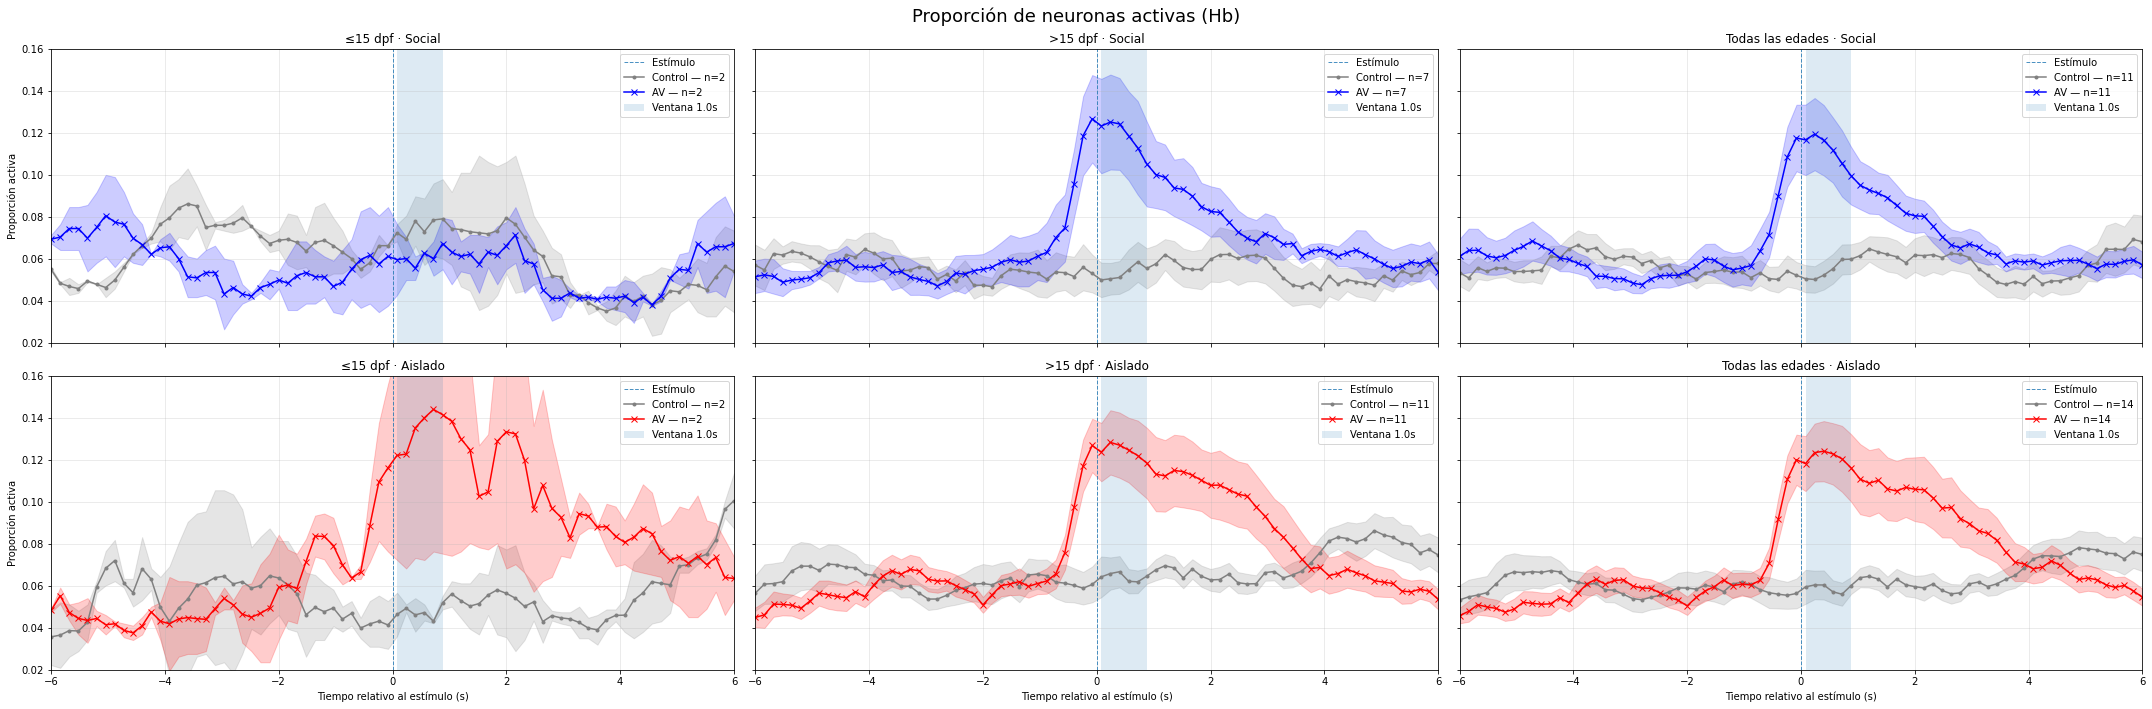

In [8]:
region_key = 'Hb'
stim_s = 23.6
win_s = 1.0
fps = 6.25

grupos = {
    "≤15 dpf": lambda e: e < 14,
    ">15 dpf": lambda e: e >= 15,
    "Todas las edades": lambda e: True
}

# os.chdir(r'H:\My Drive\Valen Agulló\SAN 2025')

def _get_condition(trial):
    return 'AV' if getattr(trial, 'vis', 0) == 1 and getattr(trial, 'aud', 0) == 1 else 'C'

def _trial_timebase(trial, fallback_fps):
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft, dtype=float)
        fps_est = 1 / np.median(np.diff(ft)) if len(ft) > 1 else fallback_fps
        return ft, fps_est

    t_fps = getattr(trial, 'fps', fallback_fps)
    if t_fps is None:
        raise ValueError("Falta fps.")

    rb = getattr(trial, 'roi_binaries_rea', None)
    if rb is None or region_key not in rb:
        raise ValueError(f"Falta roi_binaries_rea['{region_key}'].")

    n_frames = np.asarray(rb[region_key]).shape[1]
    return np.arange(n_frames) / t_fps, t_fps

def _prop_active_per_frame(trial):
    rb = getattr(trial, 'roi_binaries_rea', None)
    if rb is None or region_key not in rb:
        return None
    return (np.asarray(rb[region_key]) > 0).mean(axis=0)

def _truncate(arrays):
    if not arrays:
        return [], 0
    m = min(map(len, arrays))
    return [a[:m] for a in arrays], m

def _mean_sem(traces):
    X, m = _truncate(traces)
    if m == 0:
        return None, None
    X = np.vstack(X)
    mean = X.mean(axis=0)
    sem = X.std(axis=0, ddof=1) / np.sqrt(len(X)) if len(X) > 1 else np.zeros(m)
    return mean, sem


# resultados[grupo][Social/Aislado][C/AV]
resultados = {
    g: {s: {c: {"animals": [], "t": None} for c in ["C", "AV"]}
        for s in ["Social", "Aislado"]}
    for g in grupos
}

for k, area in areas.items():
    edad = int(getattr(area, 'edad', -999))
    aislado = getattr(area, 'aislado', None)

    if aislado == 0:
        social = "Social"
    elif aislado == 1:
        social = "Aislado"
    else:
        continue

    grupos_animal = [g for g, pred in grupos.items() if pred(edad)]
    per_trial = {"C": [], "AV": []}
    per_time = {"C": [], "AV": []}

    for tr in getattr(area, 'trials_rea', []):
        cond = _get_condition(tr)
        try:
            t, _ = _trial_timebase(tr, fps)
            prop = _prop_active_per_frame(tr)
            if prop is None:
                continue
            m = min(len(t), len(prop))
            per_trial[cond].append(prop[:m])
            per_time[cond].append(t[:m])
        except Exception as e:
            print(f"[WARNING] {k}: {e}")

    for cond in ["C", "AV"]:
        series, m = _truncate(per_trial[cond])
        if m == 0:
            continue

        times, _ = _truncate(per_time[cond])
        animal_mean = np.vstack(series).mean(axis=0)
        t_common = times[0][:m]

        for g in grupos_animal:
            resultados[g][social][cond]["animals"].append(animal_mean)
            if resultados[g][social][cond]["t"] is None:
                resultados[g][social][cond]["t"] = t_common


# =================================================================
# UNA FIGURA: 2 filas × 3 columnas
# =================================================================

fig, axes = plt.subplots(2, 3, figsize=(30, 10), sharex=True, sharey=True)

for col, gname in enumerate(grupos):
    for row, social in enumerate(["Social", "Aislado"]):
        ax = axes[row, col]
        data = resultados[gname][social]

        mean_C, sem_C = _mean_sem(data["C"]["animals"])
        mean_AV, sem_AV = _mean_sem(data["AV"]["animals"])

        ref = data["AV"] if mean_AV is not None else data["C"]
        mean_ref = mean_AV if mean_AV is not None else mean_C

        if mean_ref is None:
            ax.set_title(f"{gname} · {social}\nSin datos")
            continue

        t = ref["t"][:len(mean_ref)] - stim_s
        color_AV = "blue" if social == "Social" else "red"

        # Ventana 1 s post-estímulo
        w = (t >= 0) & (t < win_s)
        if w.any():
            ax.axvspan(t[w][0], t[w][-1], alpha=.15, label=f"Ventana {win_s:.1f}s")

        ax.axvline(0, linestyle="--", linewidth=1, alpha=.8, label="Estímulo")

        if mean_C is not None:
            m = min(len(t), len(mean_C))
            ax.plot(t[:m], mean_C[:m], color="gray", marker=".",
                    label=f"Control — n={len(data['C']['animals'])}")
            if sem_C is not None:
                ax.fill_between(t[:m], mean_C[:m]-sem_C[:m],
                                mean_C[:m]+sem_C[:m], color="gray", alpha=.2)

        if mean_AV is not None:
            m = min(len(t), len(mean_AV))
            ax.plot(t[:m], mean_AV[:m], color=color_AV, marker="x",
                    label=f"AV — n={len(data['AV']['animals'])}")
            if sem_AV is not None:
                ax.fill_between(t[:m], mean_AV[:m]-sem_AV[:m],
                                mean_AV[:m]+sem_AV[:m], color=color_AV, alpha=.2)

        ax.set_title(f"{gname} · {social}")
        ax.set_xlim(-6, 6)
        ax.set_ylim(.02, .16)
        ax.grid(alpha=.3)
        ax.legend()

        if row == 1:
            ax.set_xlabel("Tiempo relativo al estímulo (s)")
        if col == 0:
            ax.set_ylabel("Proporción activa")

fig.suptitle("Proporción de neuronas activas (Hb)", fontsize=18)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

# Trazas de neuronas solas

Candidatos (≥4 trials) — Social: 10, Aislado: 14
Social: '165-1' — 9 neuronas elegibles
Aislado: '162-1' — 17 neuronas elegibles


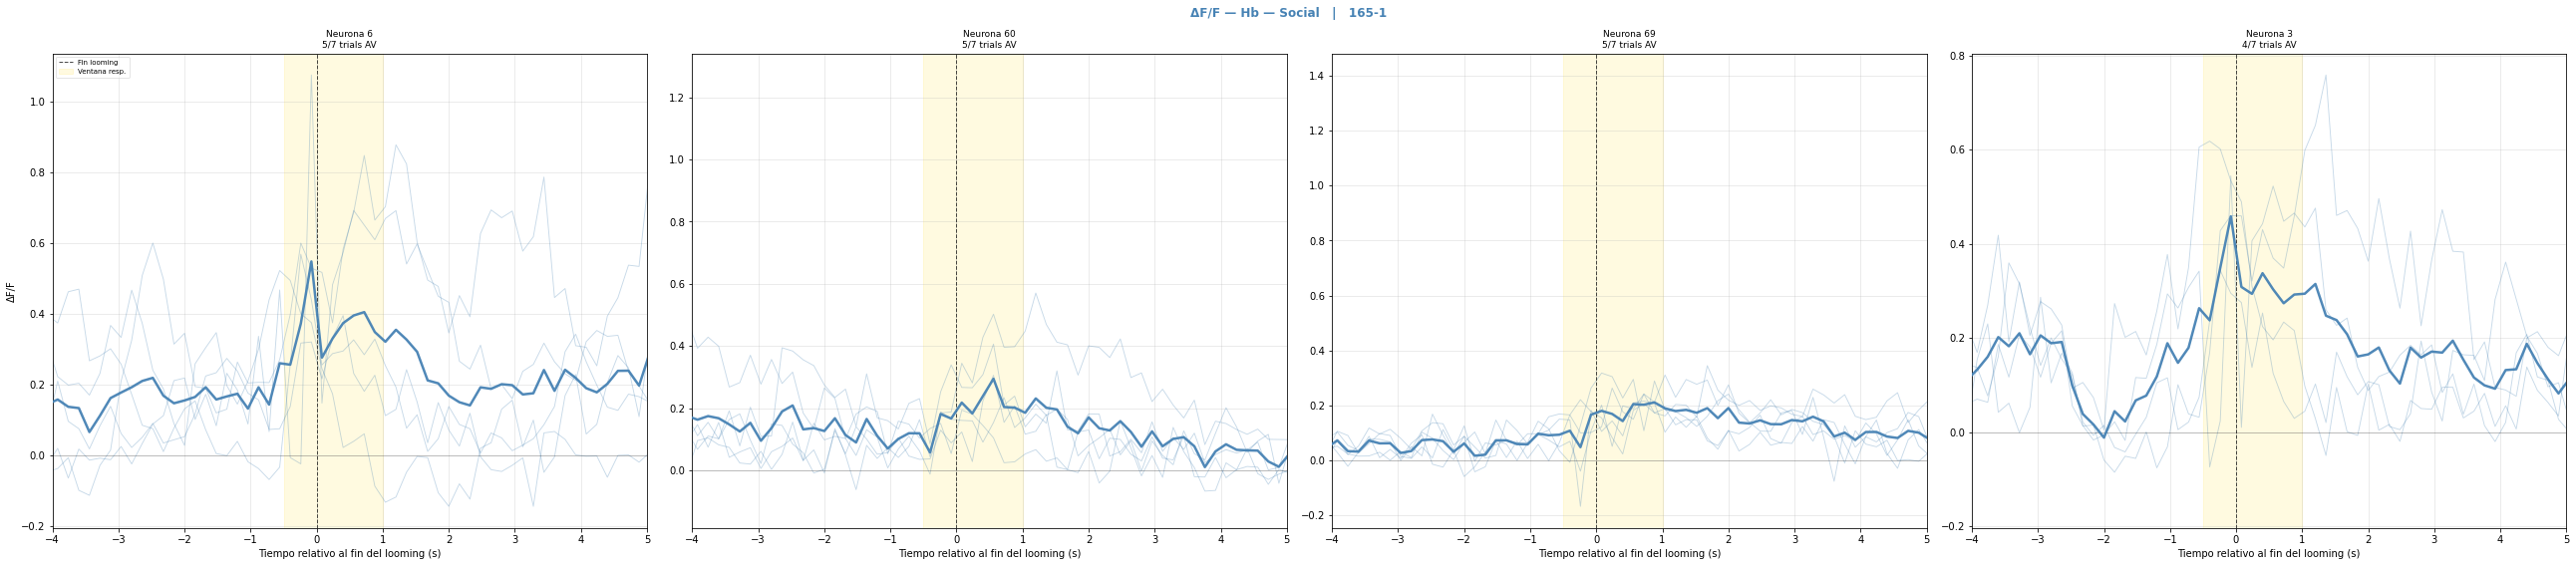

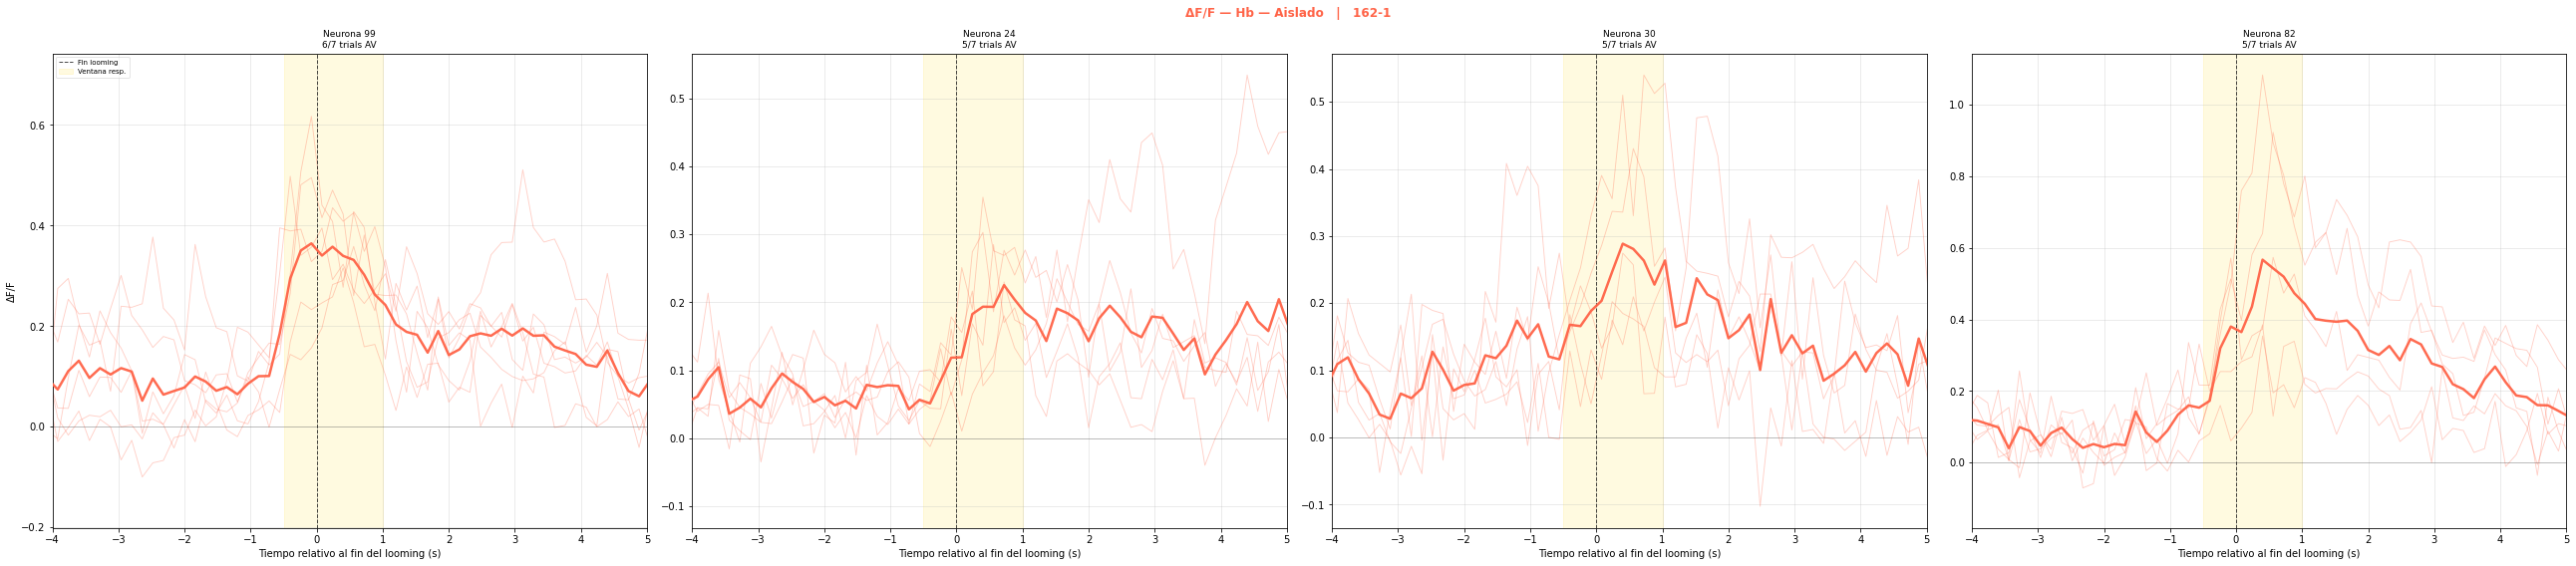

In [61]:
# ─── Parámetros ──────────────────────────────────────────────────────────────
region_key      = 'Hb'
stim_s          = 23.6       # tiempo absoluto del final del looming (punto de alineación)
resp_win_rel    = (-0.5, 1.0) # ventana de respuesta en tiempo relativo (s)
fps_fallback    = 6.25
N_NEURONS       = 4           # neuronas a mostrar por animal
MIN_RESP_TRIALS = 4           # mínimo de trials AV con respuesta
XLIM            = (-4, 5)     # eje x (s relativos al final del looming)
DFF_ATTR        = 'roi_dffs_rea'

# ─── Helpers ─────────────────────────────────────────────────────────────────
def _get_condition(trial):
    return 'AV' if getattr(trial, 'vis', 0) == 1 and getattr(trial, 'aud', 0) == 1 else 'C'

def _trial_timebase(trial, fallback_fps):
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft, dtype=float)
        return ft, (1 / np.median(np.diff(ft)) if len(ft) > 1 else fallback_fps)
    t_fps = getattr(trial, 'fps', fallback_fps)
    rb = getattr(trial, 'roi_binaries_rea', None)
    if rb is None or region_key not in rb:
        raise ValueError(f"Sin roi_binaries_rea['{region_key}'].")
    n_frames = np.asarray(rb[region_key]).shape[1]
    return np.arange(n_frames) / t_fps, t_fps

def _get_dff(trial, nid):
    d = getattr(trial, DFF_ATTR, None)
    if d is None or region_key not in d:
        return None
    return np.asarray(d[region_key])[nid].astype(float)

def _trial_responds(bin_row, t_rel):
    """True si hay actividad binarizada dentro de resp_win_rel."""
    mask = (t_rel >= resp_win_rel[0]) & (t_rel <= resp_win_rel[1])
    m    = min(len(t_rel), len(bin_row))
    return bool(bin_row[:m][mask[:m]].any())

# ─── Recolectar candidatos por condición ─────────────────────────────────────
social_candidates  = []
aislado_candidates = []

for k, area in areas.items():
    aislado = getattr(area, 'aislado', None)
    if aislado == 0:
        target = social_candidates
    elif aislado == 1:
        target = aislado_candidates
    else:
        continue

    av_data = []   # una entrada por trial AV
    for tr in getattr(area, 'trials_rea', []):
        if _get_condition(tr) != 'AV':
            continue
        try:
            t, _ = _trial_timebase(tr, fps_fallback)
            rb   = getattr(tr, 'roi_binaries_rea', None)
            if rb is None or region_key not in rb:
                continue
            bin_mat = (np.asarray(rb[region_key]) > 0)   # (n_neur, n_frames)
            m       = min(len(t), bin_mat.shape[1])
            t_rel   = t[:m] - stim_s
            av_data.append({'t_rel': t_rel, 'bin_mat': bin_mat[:, :m], 'trial': tr})
        except Exception as e:
            print(f"[WARNING] {k}: {e}")

    if not av_data:
        continue

    n_neur = av_data[0]['bin_mat'].shape[0]

    # Para cada neurona: índices de los trials AV donde respondió
    neuron_resp_trials = {}
    for nid in range(n_neur):
        resp_idx = [
            ti for ti, td in enumerate(av_data)
            if _trial_responds(td['bin_mat'][nid], td['t_rel'])
        ]
        if len(resp_idx) >= MIN_RESP_TRIALS:
            neuron_resp_trials[nid] = resp_idx

    if not neuron_resp_trials:
        continue

    target.append({
        'key'               : k,
        'av_data'           : av_data,
        'neuron_resp_trials': neuron_resp_trials,
    })

print(f"Candidatos (≥{MIN_RESP_TRIALS} trials) — Social: {len(social_candidates)}, Aislado: {len(aislado_candidates)}")

# ─── Elegir UN animal por condición ──────────────────────────────────────────
# Cambiar el índice si querés un animal específico
# rng = np.random.default_rng()

def _pick(candidates, label):
    if not candidates:
        print(f"Sin candidatos para {label}.")
        return None
    i = int(rng.integers(len(candidates)))
    a = candidates[i]
    print(f"{label}: '{a['key']}' — {len(a['neuron_resp_trials'])} neuronas elegibles")
    return a

animal_social  = _pick(social_candidates,  "Social")
animal_aislado = _pick(aislado_candidates, "Aislado")

# ─── Función de graficado ────────────────────────────────────────────────────
def plot_animal(animal, condition_name, n_neurons=N_NEURONS):
    if animal is None:
        return

    nrts    = animal['neuron_resp_trials']
    av_data = animal['av_data']

    # Elegir las N neuronas con más trials respondidos
    chosen = sorted(nrts, key=lambda n: len(nrts[n]), reverse=True)[:n_neurons]

    color = "steelblue" if condition_name == "Social" else "tomato"

    fig, axes = plt.subplots(1, len(chosen),
                             figsize=(4.5*2 * len(chosen), 4*2),
                             sharey=False)
    axes = np.atleast_1d(axes)

    for ax, nid in zip(axes, chosen):
        resp_idx    = nrts[nid]
        dff_traces  = []
        t_arrays    = []

        for ti in resp_idx:
            td   = av_data[ti]
            dff  = _get_dff(td['trial'], nid)
            if dff is None:
                continue
            t_rel = td['t_rel']
            m     = min(len(t_rel), len(dff))
            dff_traces.append(dff[:m])
            t_arrays.append(t_rel[:m])
            # Trazo fino (solo trials que respondieron)
            ax.plot(t_rel[:m], dff[:m],
                    color=color, alpha=0.3, linewidth=0.9, zorder=2)

        if not dff_traces:
            ax.set_title(f"N{nid}\n(sin df/f)")
            continue

        # Trazo grueso: promedio solo sobre trials que respondieron
        min_m    = min(len(tr) for tr in dff_traces)
        t_mean   = t_arrays[0][:min_m]
        mean_dff = np.vstack([tr[:min_m] for tr in dff_traces]).mean(axis=0)
        ax.plot(t_mean, mean_dff,
                color=color, linewidth=2.5, alpha=0.95, zorder=3)

        # Decoraciones
        ax.axvline(0,  ls='--', lw=1,   color='k',    alpha=0.7, label='Fin looming')
        ax.axvspan(*resp_win_rel, alpha=0.12, color='gold', label='Ventana resp.')
        ax.axhline(0,  lw=0.5,           color='k',    alpha=0.4)
        ax.set_xlim(*XLIM)
        ax.grid(alpha=0.3)
        ax.set_title(f"Neurona {nid}\n{len(dff_traces)}/{len(av_data)} trials AV",
                     fontsize=9)
        ax.set_xlabel("Tiempo relativo al fin del looming (s)")
        if ax is axes[0]:
            ax.set_ylabel("ΔF/F")
            ax.legend(fontsize=7, loc='upper left', framealpha=0.5)

    fig.suptitle(
        f"ΔF/F — Hb — {condition_name}   |   {animal['key']}",
        fontsize=12, fontweight='bold', color=color
    )
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.show()

# ─── Generar las dos figuras ─────────────────────────────────────────────────
plot_animal(animal_social,  "Social")
plot_animal(animal_aislado, "Aislado")

# Consistencias

In [9]:
# ================================================================
# Parámetros principales
# ================================================================
region_key   = 'Hb'
stim_s       = 23.6     # segundo del estímulo
fps          = 6.25     # fps si no hay trial.frame_times
solo_social  = True      # True = solo sociales, False = solo aislados 
solo_sociales  = solo_social     # True = sociales, False = aislados
    # True = sociales, False = aislados
win_s      = 1.0          # ventana post-estímulo (s)
consistencia_en_trial =1 #Numero de veces q se prendio la neurona en la ventana en un trial >consistencia_en_trial
# Ventana de análisis alrededor del estímulo
frames_pre   = 3     # número de frames antes
frames_post  = 6        # número de frames después
# Grupos por edad (dpf)
# grupos = {
#     "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
#     "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
#     "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
# }



In [10]:
# ================================================================
# Cálculo de consistencia inter-trials y preparación del DataFrame 2026
# ================================================================
cons_max = 7  # vamos a evaluar consistencia >=1, >=2, ..., >=5
max_consistencia = cons_max
rows = []
for fish_id, area in areas.items():
    edad    = int(getattr(area, "edad", -999))
    aislado = int(getattr(area, "aislado", 1))

    # Asignar grupo etario
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    # --- Acumular trials de AV ---
    active_counts = None
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue

        try:
            t, tr_fps = _trial_timebase(tr, fps)
        except Exception:
            continue

        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        if win_idx.min()<0 or win_idx.max()>=len(t):
            continue

        rb = getattr(tr, 'roi_binaries_rea', None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        if B.ndim != 2:
            continue
        B = (B > 0).astype(float)

        active_mask = (B[:, win_idx].sum(axis=1) > consistencia_en_trial)
        if active_counts is None:
            active_counts = active_mask.astype(int)
        else:
            active_counts += active_mask.astype(int)

    if active_counts is None:
        continue

    # --- Guardar conteos por nivel de consistencia ---
    for k in range(0, cons_max+1):
        n_neuronas = (active_counts >= k).sum()
        rows.append({
            "fish_id": str(fish_id),
            "grupo": gname,
            "aislado": aislado,
            "consistencia": k,
            "n_neuronas": n_neuronas
        })

df_cons = pd.DataFrame(rows)



## Sin 0 ni color/edad

NÚMERO DE PECES POR GRUPO

All ages:
Aislado    14
Social     11
Name: condicion, dtype: int64

≥15 dpf:
Aislado    11
Social      7
Name: condicion, dtype: int64

TRIALS AV VÁLIDOS POR PEZ
fish_id  edad condicion  n_trials_AV_validos
  149-1  12.0   Aislado                    7
  151-1  12.0   Aislado                    7
  183-1  14.0   Aislado                    7
  157-1  15.0   Aislado                    7
  162-1  15.0   Aislado                    7
  164-1  15.0   Aislado                    7
  170-1  15.0   Aislado                    7
  171-1  15.0   Aislado                    7
  166-1  16.0   Aislado                    7
  185-1  16.0   Aislado                    7
  191-1  16.0   Aislado                    7
  192-1  16.0   Aislado                    7
  193-1  16.0   Aislado                    7
  177-1  17.0   Aislado                    7
  148-1  12.0    Social                    7
  150-1  12.0    Social                    7
  181-1  14.0    Social                    7


NameError: name 'Line2D' is not defined

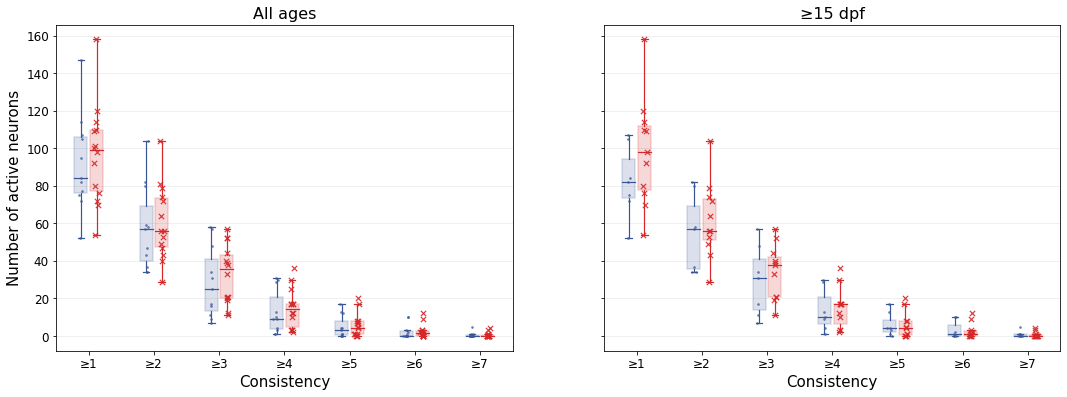

In [11]:
# ================================================================
# CONSISTENCIA 1–7 TRIALS AV
# SOCIALES vs AISLADOS
# DOS GRUPOS: TODAS LAS EDADES / ≥14 dpf
# ================================================================



# ================================================================
# PARÁMETROS
# ================================================================

max_consistencia = 7

grupos = {
    "All ages": lambda edad: True,
    "≥15 dpf":  lambda edad: edad >= 15
}


# ================================================================
# 1. CALCULAR CONSISTENCIA PARA CADA PEZ
# ================================================================

rows = []

for fish_id, area in areas.items():

    edad = getattr(area, "edad", None)
    aislado = getattr(area, "aislado", None)

    if aislado not in [0, 1]:
        continue

    if edad is None:
        continue

    condicion = "Social" if aislado == 0 else "Aislado"

    # ------------------------------------------------------------
    # Contar en cuántos trials AV responde cada neurona
    # ------------------------------------------------------------

    n_respuestas = None
    n_trials_AV_validos = 0

    for tr in getattr(area, "trials_rea", []):

        # Solo trials AV
        if _get_condition(tr) != "AV":
            continue

        rb = getattr(tr, "roi_binaries_rea", None)

        if rb is None or region_key not in rb:
            continue

        B = (np.asarray(rb[region_key]) > 0).astype(int)

        if B.ndim != 2:
            continue

        # Timebase
        t, tr_fps = _trial_timebase(tr, fps)

        stim_frame = int(round(stim_s * tr_fps))

        # Misma ventana que venimos usando
        win_idx = np.arange(
            stim_frame - frames_pre,
            stim_frame + frames_post + 1
        )

        win_idx = win_idx[
            (win_idx >= 0) &
            (win_idx < B.shape[1])
        ]

        if len(win_idx) == 0:
            continue

        # --------------------------------------------------------
        # ¿Respondió esta neurona en este trial?
        # Al menos 1 frame activo dentro de la ventana
        # --------------------------------------------------------

        resp = B[:, win_idx].sum(axis=1) > 0

        if n_respuestas is None:

            n_respuestas = resp.astype(int)

        else:

            # Seguridad por si cambia el número de neuronas
            if len(resp) != len(n_respuestas):
                continue

            n_respuestas += resp.astype(int)

        n_trials_AV_validos += 1


    if n_respuestas is None:
        continue


    # ============================================================
    # Determinar a qué grupos pertenece este pez
    # ============================================================

    grupos_animal = [
        nombre
        for nombre, predicado in grupos.items()
        if predicado(edad)
    ]


    # ============================================================
    # Guardar consistencias ≥1 ... ≥7
    # ============================================================

    for grupo in grupos_animal:

        for k in range(0, max_consistencia + 1):

            n_neuronas_consistentes = np.sum(
                n_respuestas >= k
            )

            rows.append({
                "fish_id": fish_id,
                "edad": edad,
                "aislado": aislado,
                "condicion": condicion,
                "grupo": grupo,
                "consistencia": k,
                "n_neuronas": n_neuronas_consistentes,
                "n_trials_AV_validos": n_trials_AV_validos
            })


# ================================================================
# DATAFRAME
# ================================================================

df_cons = pd.DataFrame(rows)


# ================================================================
# INFORMACIÓN DE CONTROL
# ================================================================

print("============================================================")
print("NÚMERO DE PECES POR GRUPO")
print("============================================================")

for grupo in grupos:

    aux = (
        df_cons[df_cons["grupo"] == grupo]
        [["fish_id", "condicion"]]
        .drop_duplicates()
    )

    print(f"\n{grupo}:")
    print(aux["condicion"].value_counts())


print("\n============================================================")
print("TRIALS AV VÁLIDOS POR PEZ")
print("============================================================")

print(
    df_cons[
        [
            "fish_id",
            "edad",
            "condicion",
            "n_trials_AV_validos"
        ]
    ]
    .drop_duplicates()
    .sort_values(["condicion", "edad"])
    .to_string(index=False)
)


# ================================================================
# 2. GRÁFICO
# ================================================================

order_cons = list(range(1, max_consistencia + 1))
order_cond = ["Social", "Aislado"]


colors = {
    "Social":  "#385696",
    "Aislado": "#d62728",
}

markers = {
    "Social":  ".",
    "Aislado": "x",
}

offsets = {
    "Social":  -0.12,
    "Aislado":  0.12,
}


# ================================================================
# FIGURA: 1 × 2
# ================================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 6),
    sharey=True
)

box_width = 0.20
pt_jitter = 0.018


# ================================================================
# UN PANEL POR GRUPO
# ================================================================

for ax, grupo in zip(axes, grupos):

    df_g = df_cons[
        df_cons["grupo"] == grupo
    ]

    for k in order_cons:

        base_x = float(k)

        for cond in order_cond:

            sub = df_g[
                (df_g["consistencia"] == k) &
                (df_g["condicion"] == cond)
            ]

            if sub.empty:
                continue

            pos = base_x + offsets[cond]

            y = sub["n_neuronas"].values


            # ----------------------------------------------------
            # BOXPLOT
            # ----------------------------------------------------

            bp = ax.boxplot(
                [y],
                positions=[pos],
                widths=box_width,
                showfliers=False,
                patch_artist=True
            )

            # Caja
            for patch in bp["boxes"]:

                patch.set_facecolor(colors[cond])
                patch.set_alpha(0.18)

                patch.set_edgecolor(colors[cond])
                patch.set_linewidth(1.5)


            # Mediana, whiskers y caps
            for line in (
                bp["medians"] +
                bp["whiskers"] +
                bp["caps"]
            ):

                line.set_color(colors[cond])
                line.set_linewidth(1.2)


            # ----------------------------------------------------
            # PUNTOS INDIVIDUALES = PECES
            # ----------------------------------------------------

            xs = np.random.normal(
                loc=pos,
                scale=pt_jitter,
                size=len(y)
            )

            ax.scatter(
                xs,
                y,
                s=28,
                c=colors[cond],
                marker=markers[cond],
                linewidths=1.2 if markers[cond] == "x" else 0.0,
                alpha=0.9 if cond == "Aislado" else 0.75,
                zorder=3
            )


    # ============================================================
    # EJES DE CADA PANEL
    # ============================================================

    ax.set_title(
        grupo,
        fontsize=16
    )

    ax.set_xlabel(
        "Consistency",
        fontsize=15
    )

    ax.set_xticks(order_cons)

    ax.set_xticklabels(
        [f"≥{k}" for k in order_cons],
        fontsize=12
    )

    ax.set_xlim(
        0.5,
        max_consistencia + 0.5
    )

    ax.tick_params(
        axis="y",
        labelsize=12
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )


# ================================================================
# Y LABEL
# ================================================================

axes[0].set_ylabel(
    "Number of active neurons",
    fontsize=15
)


# ================================================================
# LEYENDA
# ================================================================

handles = [

    Line2D(
        [0], [0],
        marker=".",
        color="none",
        markerfacecolor=colors["Social"],
        markersize=20,
        label="Social"
    ),

    Line2D(
        [0], [0],
        marker="x",
        color=colors["Aislado"],
        linestyle="none",
        markersize=10,
        markeredgewidth=1.5,
        label="Isolated"
    )
]

axes[1].legend(
    handles=handles,
    frameon=False,
    loc="upper right",
    fontsize=12
)


plt.tight_layout()

# plt.savefig(
#     "Consistency_all_vs_14dpf_social_isolated.pdf",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

## Con 0 y color/edad

NameError: name 'Line2D' is not defined

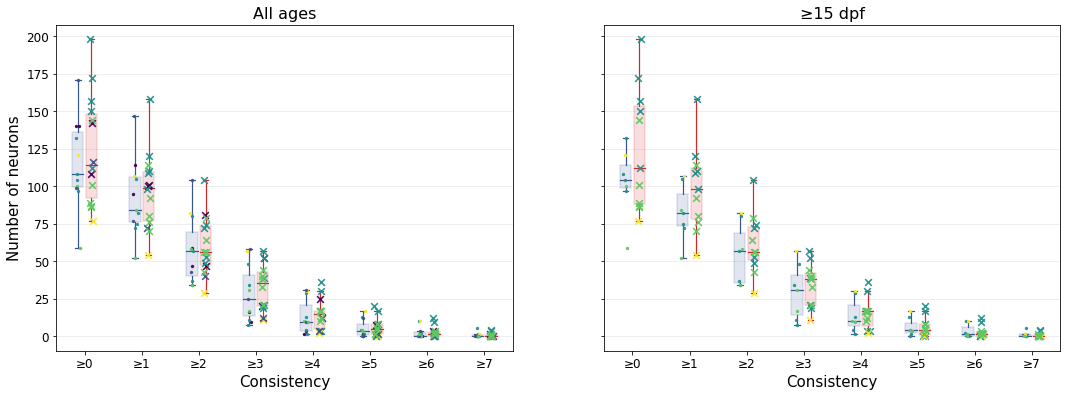

In [13]:
# ================================================================
# GRÁFICO DE CONSISTENCIA
# Color de puntos = EDAD
# Marker = Social / Aislado
# Boxplot = Social / Aislado 2026
#
# ≥0 = número total de neuronas por animal
# ================================================================



# ================================================================
# CONFIGURACIÓN
# ================================================================

# AHORA INCLUYE CONSISTENCIA 0
order_cons = list(range(0, max_consistencia + 1))
order_cond = ["Social", "Aislado"]

# ------------------------------------------------
# Color de BOXPLOTS = condición
# ------------------------------------------------

box_colors = {
    "Social":  "#385696",
    "Aislado": "#d62728",
}

# ------------------------------------------------
# Marker = condición
# ------------------------------------------------

markers = {
    "Social":  ".",
    "Aislado": "x",
}

# ------------------------------------------------
# Color de PUNTOS = edad
# ------------------------------------------------

age_colors = {
    12: "#440154",   # violeta
    14: "#3b528b",   # azul
    15: "#21918c",   # verde/azulado
    16: "#5ec962",   # verde
    17: "#fde725",   # amarillo
}

# ------------------------------------------------
# Posición Social / Aislado
# ------------------------------------------------

offsets = {
    "Social":  -0.12,
    "Aislado":  0.12,
}


# ================================================================
# FIGURA
# ================================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 6),
    sharey=True
)

box_width = 0.20
pt_jitter = 0.018

# Para que el jitter sea siempre igual cada vez que ejecutás
rng = np.random.default_rng(12345)


# ================================================================
# UN PANEL POR GRUPO
# ================================================================

for ax, grupo in zip(axes, grupos):

    df_g = df_cons[
        df_cons["grupo"] == grupo
    ]

    for k in order_cons:

        base_x = float(k)

        for cond in order_cond:

            sub = df_g[
                (df_g["consistencia"] == k) &
                (df_g["condicion"] == cond)
            ]

            if sub.empty:
                continue

            pos = base_x + offsets[cond]

            y = sub["n_neuronas"].values


            # ====================================================
            # BOXPLOT
            # Color = condición
            # ====================================================

            bp = ax.boxplot(
                [y],
                positions=[pos],
                widths=box_width,
                showfliers=False,
                patch_artist=True
            )

            for patch in bp["boxes"]:

                patch.set_facecolor(box_colors[cond])
                patch.set_alpha(0.15)

                patch.set_edgecolor(box_colors[cond])
                patch.set_linewidth(1.5)


            for line in (
                bp["medians"] +
                bp["whiskers"] +
                bp["caps"]
            ):

                line.set_color(box_colors[cond])
                line.set_linewidth(1.2)


            # ====================================================
            # PUNTOS INDIVIDUALES
            #
            # COLOR  = edad
            # MARKER = condición
            # ====================================================

            for _, row in sub.iterrows():

                edad = int(row["edad"])

                # jitter individual
                x = rng.normal(
                    loc=pos,
                    scale=pt_jitter
                )

                ax.scatter(
                    x,
                    row["n_neuronas"],

                    s=45,

                    color=age_colors[edad],

                    marker=markers[cond],

                    linewidths=1.6 if cond == "Aislado" else 0,

                    alpha=0.95,

                    zorder=3
                )


    # ============================================================
    # EJES
    # ============================================================

    ax.set_title(
        grupo,
        fontsize=16
    )

    ax.set_xlabel(
        "Consistency",
        fontsize=15
    )

    ax.set_xticks(order_cons)

    ax.set_xticklabels(
        [f"≥{k}" for k in order_cons],
        fontsize=12
    )

    # MODIFICADO PARA INCLUIR ≥0
    ax.set_xlim(
        -0.5,
        max_consistencia + 0.5
    )

    ax.tick_params(
        axis="y",
        labelsize=12
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )


# ================================================================
# EJE Y
# ================================================================

axes[0].set_ylabel(
    "Number of neurons",
    fontsize=15
)


# ================================================================
# LEYENDA 1 — CONDICIÓN
# ================================================================

condition_handles = [

    Line2D(
        [0], [0],
        marker=".",
        color="black",
        linestyle="none",
        markersize=15,
        label="Social"
    ),

    Line2D(
        [0], [0],
        marker="x",
        color="black",
        linestyle="none",
        markersize=9,
        markeredgewidth=1.5,
        label="Isolated"
    )
]

legend_condition = axes[1].legend(
    handles=condition_handles,
    title="Condition",
    frameon=False,
    loc="upper right",
    fontsize=11,
    title_fontsize=11
)

axes[1].add_artist(legend_condition)


# ================================================================
# LEYENDA 2 — EDAD
# ================================================================

age_handles = [

    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=age_colors[edad],
        markeredgecolor="none",
        markersize=8,
        label=f"{edad} dpf"
    )

    for edad in [12, 14, 15, 16, 17]
]

axes[1].legend(
    handles=age_handles,
    title="Age",
    frameon=False,
    loc="center right",
    fontsize=11,
    title_fontsize=11
)


plt.tight_layout()

# plt.savefig(
#     "Consistency_by_age_social_isolated.pdf",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

## Distribución respuestas

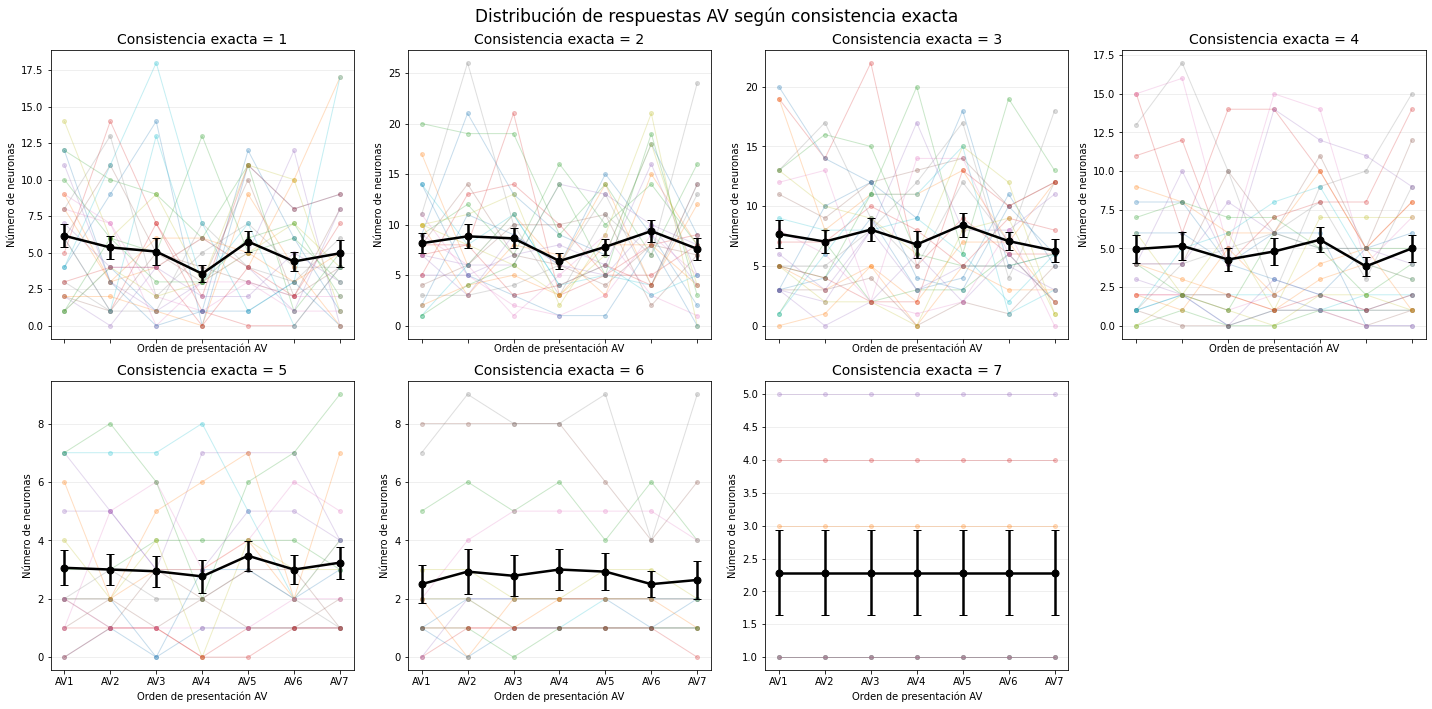

In [15]:
# ================================================================
# RESPUESTA SEGÚN PRESENTACIÓN AV POR CONSISTENCIA EXACTA
#
# 7 gráficos:
#   Consistencia exacta 1
#   Consistencia exacta 2
#   ...
#   Consistencia exacta 7
#
# X = presentación AV (AV1, AV2...)
# Y = número de neuronas que respondieron
#
# Cada línea fina = un animal
# Línea negra = promedio ± SEM
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ================================================================
# CALCULAR POR ANIMAL
# ================================================================

resultados_exactos = {
    k: {} for k in range(1, 8)
}

for fish_id, area in areas.items():

    respuestas_AV = []

    # ------------------------------------------------------------
    # Respuesta de cada neurona en cada presentación AV
    # ------------------------------------------------------------

    for tr in getattr(area, "trials_rea", []):

        if _get_condition(tr) != "AV":
            continue

        rb = getattr(tr, "roi_binaries_rea", None)
        if rb is None or region_key not in rb:
            continue

        B = (np.asarray(rb[region_key]) > 0).astype(int)

        _, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))

        win_idx = np.arange(
            stim_frame - frames_pre,
            stim_frame + frames_post + 1
        )

        win_idx = win_idx[
            (win_idx >= 0) &
            (win_idx < B.shape[1])
        ]

        if len(win_idx) == 0:
            continue

        # True/False para cada neurona en este AV
        respondieron = B[:, win_idx].sum(axis=1) > 0

        respuestas_AV.append(respondieron)


    if len(respuestas_AV) == 0:
        continue


    # ------------------------------------------------------------
    # Matriz:
    # filas    = neuronas
    # columnas = AV1, AV2...
    # ------------------------------------------------------------

    n_neuronas = min(len(x) for x in respuestas_AV)

    respuestas = np.column_stack([
        x[:n_neuronas]
        for x in respuestas_AV
    ])

    # Consistencia EXACTA de cada neurona
    consistencia_exacta = respuestas.sum(axis=1)


    # ------------------------------------------------------------
    # Separar por consistencia exacta
    # ------------------------------------------------------------

    for k in range(1, 8):

        mask = consistencia_exacta == k

        if not np.any(mask):
            continue

        # Sólo neuronas de consistencia exacta k
        resp_k = respuestas[mask]

        # Cuántas respondieron en AV1, AV2, ...
        n_por_AV = resp_k.sum(axis=0)

        resultados_exactos[k][fish_id] = n_por_AV


# ================================================================
# FIGURA — 7 PANELES
# ================================================================

fig, axes = plt.subplots(
    2, 4,
    figsize=(20, 10),
    sharex=True
)

axes = axes.flatten()


for k in range(1, 8):

    ax = axes[k - 1]

    datos = resultados_exactos[k]

    if len(datos) == 0:
        ax.set_title(f"Consistencia exacta = {k}")
        continue

    # Todos con misma cantidad de AV
    n_AV = min(len(x) for x in datos.values())

    matriz = np.vstack([
        x[:n_AV]
        for x in datos.values()
    ])

    x = np.arange(1, n_AV + 1)


    # ------------------------------------------------------------
    # Animales individuales
    # ------------------------------------------------------------

    for fila in matriz:

        ax.plot(
            x,
            fila,
            marker="o",
            markersize=4,
            linewidth=1,
            alpha=0.25
        )


    # ------------------------------------------------------------
    # Promedio ± SEM entre animales
    # ------------------------------------------------------------

    media = np.mean(matriz, axis=0)

    if matriz.shape[0] > 1:
        sem = np.std(
            matriz,
            axis=0,
            ddof=1
        ) / np.sqrt(matriz.shape[0])
    else:
        sem = np.zeros(n_AV)


    ax.errorbar(
        x,
        media,
        yerr=sem,
        color="black",
        marker="o",
        markersize=7,
        linewidth=2.5,
        capsize=4,
        label="Promedio ± SEM",
        zorder=5
    )


    # ------------------------------------------------------------
    # EJES
    # ------------------------------------------------------------

    ax.set_title(
        f"Consistencia exacta = {k}",
        fontsize=14
    )

    ax.set_xticks(x)

    ax.set_xticklabels([
        f"AV{i}" for i in x
    ])

    ax.set_xlabel(
        "Orden de presentación AV"
    )

    ax.set_ylabel(
        "Número de neuronas"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )


# ================================================================
# ELIMINAR PANEL SOBRANTE
# ================================================================

axes[7].axis("off")


# ================================================================
# TÍTULO GENERAL
# ================================================================

fig.suptitle(
    "Distribución de respuestas AV según consistencia exacta",
    fontsize=17
)

plt.tight_layout()
plt.show()

# AUC

## AUC con bin


================ DATOS POR PEZ ================



,fish_id,edad,condicion,n_neuronas,n_perfiles,AUC_cola,pendiente_cola
0,148-1,12.0,Social,3,13,0.321333,-0.098684
1,149-1,12.0,Aislado,12,59,0.348254,-0.004646
2,150-1,12.0,Social,1,4,0.060000,0.002741
3,151-1,12.0,Aislado,25,109,0.441120,-0.073636
4,154-1,15.0,Social,4,17,0.048000,-0.014190
5,156-1,15.0,Social,1,4,0.000000,0.000000
6,157-1,15.0,Aislado,36,173,0.615074,-0.117065
7,159-1,15.0,Social,13,59,0.179502,-0.004646
8,162-1,15.0,Aislado,17,78,0.380078,-0.072959
9,164-1,15.0,Aislado,3,12,0.340000,-0.084064



================ DATOS POR NEURONA ================



,fish_id,edad,condicion,neuron,n_trials,AUC_neurona
0,148-1,12.0,Social,6,5,0.224
1,148-1,12.0,Social,118,4,0.260
2,148-1,12.0,Social,130,4,0.480
3,149-1,12.0,Aislado,3,5,0.096
4,149-1,12.0,Aislado,5,5,0.560
...,...,...,...,...,...,...
339,193-1,16.0,Aislado,38,4,1.040
340,193-1,16.0,Aislado,44,4,0.800
341,193-1,16.0,Aislado,45,4,0.020
342,193-1,16.0,Aislado,55,6,0.240



Jerarquía AUC: trial → promedio por neurona → promedio por pez

TEST 1 — AUC DE LA COLA
Intervalo: 2.0–5.0 s

Social: 0.2488 ± 0.0513 (media ± SEM, n=11)
Aislado: 0.4929 ± 0.0566 (media ± SEM, n=14)

Diferencia Aislado - Social: 0.2441
IC95%: [0.0861, 0.4021]

Welch t(22.97) = -3.195, p = 0.004026
Mann-Whitney U = 28.0, p = 0.007928
Hedges' g = 1.212

TEST 2 — PENDIENTE DE LA COLA
Intervalo: 2.0–5.0 s

Social: -0.0514 ± 0.0128 (media ± SEM, n=11)
Aislado: -0.0905 ± 0.0120 (media ± SEM, n=14)

Diferencia Aislado - Social: -0.0391
IC95%: [-0.0755, -0.0028]

Welch t(22.12) = 2.230, p = 0.036189
Mann-Whitney U = 112.0, p = 0.058932
Hedges' g = -0.863

--- INTERPRETACIÓN AUC ---
RESULTADO ESTADÍSTICAMENTE SIGNIFICATIVO (p < 0.05).
Los animales AISLADOS presentan un AUC significativamente mayor.

--- INTERPRETACIÓN PENDIENTE ---
RESULTADO ESTADÍSTICAMENTE SIGNIFICATIVO (p < 0.05).
La pendiente de los AISLADOS es más negativa: compatible con un decaimiento más rápido.

CONCLUSIÓN CONJUNTA
AU

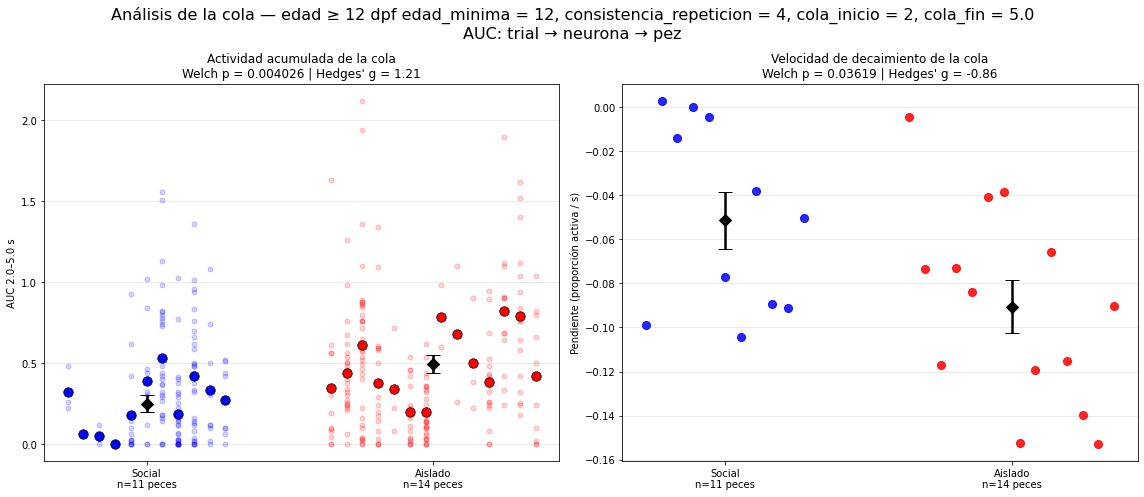

In [18]:
# ================================================================
# HIPÓTESIS 2 — ESTADÍSTICA DE LA COLA 2026
#
# AUC:
# trial → promedio por neurona → promedio por pez
#
# Cada neurona tiene el mismo peso dentro del pez,
# independientemente de cuántos trials haya respondido.
# UNIDAD ESTADÍSTICA FINAL = PEZ
# ================================================================

# ================================================================
# PARÁMETROS
# ================================================================
from scipy import stats

alpha = 0.05

edad_minima = 12
consistencia_repeticion = 4

cola_inicio = 2
cola_fin = 5.0

# ================================================================
# FUNCIONES AUXILIARES
# ================================================================

def calcular_auc(y, t):
    return np.trapezoid(y, t) if hasattr(np, "trapezoid") else np.trapz(y, t)


def get_consistent_mask_original(area):
    n_respuestas = None

    for tr in getattr(area, "trials_rea", []):
        if _get_condition(tr) != "AV":
            continue

        rb = getattr(tr, "roi_binaries_rea", None)
        if rb is None or region_key not in rb:
            continue

        B = (np.asarray(rb[region_key]) > 0).astype(int)
        _, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))

        win_idx = np.arange(
            stim_frame - frames_pre,
            stim_frame + frames_post + 1
        )
        win_idx = win_idx[(win_idx >= 0) & (win_idx < B.shape[1])]

        if len(win_idx) == 0:
            continue

        resp = B[:, win_idx].sum(axis=1) > 0
        n_respuestas = (
            resp.astype(int)
            if n_respuestas is None
            else n_respuestas + resp.astype(int)
        )

    if n_respuestas is None:
        return None

    return n_respuestas >= consistencia_repeticion


# ================================================================
# PROCESAMIENTO
#
# Guardamos:
#   df_auc_trial   → un AUC por neurona × trial
#   df_auc_neurona → promedio de trials de cada neurona
#   df_cola        → promedio de neuronas de cada pez
# ================================================================

filas_trial = []
filas_neurona = []
filas_pez = []

for fish_id, area in areas.items():

    aislado = getattr(area, "aislado", None)
    edad = getattr(area, "edad", np.nan)

    if edad is None or not np.isfinite(edad) or edad < edad_minima:
        continue
    if aislado not in [0, 1]:
        continue

    condicion = "Social" if aislado == 0 else "Aislado"

    active_mask = get_consistent_mask_original(area)
    if active_mask is None or not active_mask.any():
        continue

    consistent_indices = np.where(active_mask)[0]

    # AUCs de trials válidos agrupados por neurona
    aucs_por_neurona = {n: [] for n in consistent_indices}

    # Se mantienen para calcular la pendiente como antes
    perfiles_pez = []
    tiempos_pez = []

    av_trial_n = 0

    for tr in getattr(area, "trials_rea", []):

        if _get_condition(tr) != "AV":
            continue

        av_trial_n += 1

        rb = getattr(tr, "roi_binaries_rea", None)
        if rb is None or region_key not in rb:
            continue

        B = (np.asarray(rb[region_key]) > 0).astype(int)

        if len(active_mask) != B.shape[0]:
            continue

        t, tr_fps = _trial_timebase(tr, fps)
        t_rel = t - stim_s
        stim_frame = int(round(stim_s * tr_fps))

        # Ventana original: define si la neurona respondió en este trial
        win_idx = np.arange(
            stim_frame - frames_pre,
            stim_frame + frames_post + 1
        )
        win_idx = win_idx[(win_idx >= 0) & (win_idx < B.shape[1])]

        if len(win_idx) == 0:
            continue

        # Cola donde calculamos AUC
        mask_cola = (t_rel >= cola_inicio) & (t_rel <= cola_fin)
        if mask_cola.sum() < 2:
            continue

        t_cola = t_rel[mask_cola]

        # Intervalo usado para conservar la pendiente del análisis anterior
        plot_mask = (t_rel >= -1) & (t_rel <= cola_fin)
        t_plot = t_rel[plot_mask]

        for neuron_idx in consistent_indices:

            trace = B[neuron_idx]

            # Sólo entra si respondió en ESTE trial
            if trace[win_idx].sum() == 0:
                continue

            # AUC de esta neurona en este trial
            auc_trial = calcular_auc(trace[mask_cola], t_cola)
            aucs_por_neurona[neuron_idx].append(auc_trial)

            filas_trial.append({
                "fish_id": fish_id,
                "edad": edad,
                "condicion": condicion,
                "neuron": neuron_idx,
                "trial": av_trial_n,
                "AUC_trial": auc_trial
            })

            perfiles_pez.append(trace[plot_mask])
            tiempos_pez.append(t_plot)

    # ============================================================
    # NIVEL NEURONA:
    # promedio de AUCs de sus trials válidos
    # ================================================================

    aucs_neuronas_pez = []

    for neuron_idx, aucs_trials in aucs_por_neurona.items():

        if not aucs_trials:
            continue

        auc_neurona = np.mean(aucs_trials)
        aucs_neuronas_pez.append(auc_neurona)

        filas_neurona.append({
            "fish_id": fish_id,
            "edad": edad,
            "condicion": condicion,
            "neuron": neuron_idx,
            "n_trials": len(aucs_trials),
            "AUC_neurona": auc_neurona
        })

    if not aucs_neuronas_pez:
        continue

    # ============================================================
    # NIVEL PEZ:
    # promedio de AUCs neuronales → todas las neuronas pesan igual
    # ================================================================

    auc_pez = np.mean(aucs_neuronas_pez)

    # Pendiente: se mantiene igual que en el análisis anterior
    pendiente_pez = np.nan

    if perfiles_pez:
        min_len = min(map(len, perfiles_pez))
        perfiles_array = np.vstack([x[:min_len] for x in perfiles_pez])
        t_pez = tiempos_pez[0][:min_len]
        curva_pez = perfiles_array.mean(axis=0)

        mask = (t_pez >= cola_inicio) & (t_pez <= cola_fin)

        if mask.sum() >= 2:
            pendiente_pez = stats.linregress(
                t_pez[mask],
                curva_pez[mask]
            ).slope

    filas_pez.append({
        "fish_id": fish_id,
        "edad": edad,
        "condicion": condicion,
        "n_neuronas": len(aucs_neuronas_pez),
        "n_perfiles": len(perfiles_pez),
        "AUC_cola": auc_pez,
        "pendiente_cola": pendiente_pez
    })


# ================================================================
# DATAFRAMES
# ================================================================

df_auc_trial = pd.DataFrame(filas_trial)
df_auc_neurona = pd.DataFrame(filas_neurona)
df_cola = pd.DataFrame(filas_pez)

print("\n================ DATOS POR PEZ ================\n")
display(df_cola)

print("\n================ DATOS POR NEURONA ================\n")
display(df_auc_neurona)

print("\nJerarquía AUC: trial → promedio por neurona → promedio por pez")


# ================================================================
# ESTADÍSTICA
# ================================================================

def hedges_g(social, aislado):
    n1, n2 = len(social), len(aislado)
    s1, s2 = np.std(social, ddof=1), np.std(aislado, ddof=1)

    pooled = np.sqrt(
        ((n1 - 1)*s1**2 + (n2 - 1)*s2**2) /
        (n1 + n2 - 2)
    )

    if pooled == 0:
        return np.nan

    d = (np.mean(aislado) - np.mean(social)) / pooled
    correction = 1 - 3 / (4*(n1 + n2) - 9)

    return correction*d


def comparar_grupos(variable):

    social = df_cola.loc[
        df_cola["condicion"] == "Social", variable
    ].dropna().values

    aislado = df_cola.loc[
        df_cola["condicion"] == "Aislado", variable
    ].dropna().values

    if len(social) < 2 or len(aislado) < 2:
        raise ValueError("No hay suficientes peces.")

    mean_s, mean_a = np.mean(social), np.mean(aislado)
    sem_s, sem_a = stats.sem(social), stats.sem(aislado)
    diferencia = mean_a - mean_s

    welch = stats.ttest_ind(social, aislado, equal_var=False)

    n1, n2 = len(social), len(aislado)
    v1, v2 = np.var(social, ddof=1), np.var(aislado, ddof=1)

    se = np.sqrt(v1/n1 + v2/n2)

    welch_df = (
        (v1/n1 + v2/n2)**2 /
        ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    )

    tcrit = stats.t.ppf(.975, welch_df)

    mw = stats.mannwhitneyu(
        social,
        aislado,
        alternative="two-sided"
    )

    return {
        "social": social,
        "aislado": aislado,
        "mean_social": mean_s,
        "mean_aislado": mean_a,
        "sem_social": sem_s,
        "sem_aislado": sem_a,
        "diferencia": diferencia,
        "welch": welch,
        "welch_df": welch_df,
        "ci_low": diferencia - tcrit*se,
        "ci_high": diferencia + tcrit*se,
        "mw": mw,
        "g": hedges_g(social, aislado)
    }


res_auc = comparar_grupos("AUC_cola")
res_slope = comparar_grupos("pendiente_cola")


# ================================================================
# RESULTADOS
# ================================================================

def imprimir_resultado(res, nombre):

    print("\n" + "="*60)
    print(nombre)
    print(f"Intervalo: {cola_inicio:.1f}–{cola_fin:.1f} s")
    print("="*60)

    print(
        f"\nSocial: {res['mean_social']:.4f} ± "
        f"{res['sem_social']:.4f} "
        f"(media ± SEM, n={len(res['social'])})"
    )

    print(
        f"Aislado: {res['mean_aislado']:.4f} ± "
        f"{res['sem_aislado']:.4f} "
        f"(media ± SEM, n={len(res['aislado'])})"
    )

    print(f"\nDiferencia Aislado - Social: {res['diferencia']:.4f}")
    print(f"IC95%: [{res['ci_low']:.4f}, {res['ci_high']:.4f}]")

    print(
        f"\nWelch t({res['welch_df']:.2f}) = "
        f"{res['welch'].statistic:.3f}, "
        f"p = {res['welch'].pvalue:.6f}"
    )

    print(
        f"Mann-Whitney U = {res['mw'].statistic:.1f}, "
        f"p = {res['mw'].pvalue:.6f}"
    )

    print(f"Hedges' g = {res['g']:.3f}")


imprimir_resultado(res_auc, "TEST 1 — AUC DE LA COLA")
imprimir_resultado(res_slope, "TEST 2 — PENDIENTE DE LA COLA")


# ================================================================
# INTERPRETACIÓN AUTOMÁTICA
# ================================================================

print("\n--- INTERPRETACIÓN AUC ---")

if res_auc["welch"].pvalue < alpha:
    mayor = "AISLADOS" if res_auc["diferencia"] > 0 else "SOCIALES"
    print(f"RESULTADO ESTADÍSTICAMENTE SIGNIFICATIVO (p < {alpha}).")
    print(f"Los animales {mayor} presentan un AUC significativamente mayor.")
else:
    print(
        f"NO se detectó una diferencia estadísticamente "
        f"significativa en el AUC (p >= {alpha})."
    )


print("\n--- INTERPRETACIÓN PENDIENTE ---")

if res_slope["welch"].pvalue < alpha:
    print(f"RESULTADO ESTADÍSTICAMENTE SIGNIFICATIVO (p < {alpha}).")

    if res_slope["diferencia"] > 0:
        print(
            "La pendiente de los AISLADOS es menos negativa: "
            "compatible con un decaimiento más lento."
        )
    else:
        print(
            "La pendiente de los AISLADOS es más negativa: "
            "compatible con un decaimiento más rápido."
        )
else:
    print(
        f"NO se detectó una diferencia estadísticamente "
        f"significativa en la pendiente (p >= {alpha})."
    )


print("\n" + "="*60)
print("CONCLUSIÓN CONJUNTA")
print("="*60)

sig_auc = res_auc["welch"].pvalue < alpha
sig_slope = res_slope["welch"].pvalue < alpha

if sig_auc and sig_slope:
    print("AUC Y pendiente presentan diferencias significativas.")
elif sig_auc:
    print("El AUC presenta una diferencia significativa, pero la pendiente NO.")
elif sig_slope:
    print("La pendiente presenta una diferencia significativa, pero el AUC NO.")
else:
    print("NINGUNO presenta una diferencia estadísticamente significativa.")


# ================================================================
# FIGURA RESUMEN
#
# AUC:
#   punto claro = AUC promedio de UNA NEURONA
#   punto grande = AUC promedio del PEZ
#   diamante negro = media ± SEM entre peces
#
# Cada pez tiene una X fija y distinta, sin jitter aleatorio.
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
spacing = .055

# ================================================================
# PANEL 1 — AUC
# ================================================================

ax = axes[0]

for center, condicion, color in [
    (0, "Social", "blue"),
    (1, "Aislado", "red")
]:

    peces = (
        df_cola[df_cola["condicion"] == condicion]
        .sort_values("fish_id")
        .reset_index(drop=True)
    )

    offsets = (
        np.arange(len(peces)) -
        (len(peces)-1)/2
    ) * spacing

    xs = center + offsets

    for x, (_, pez) in zip(xs, peces.iterrows()):

        aucs_n = df_auc_neurona.loc[
            df_auc_neurona["fish_id"] == pez["fish_id"],
            "AUC_neurona"
        ].dropna().values

        # Puntos claros = neuronas que forman el promedio del pez
        ax.scatter(
            np.full(len(aucs_n), x),
            aucs_n,
            color=color,
            alpha=.18,
            s=25,
            zorder=2
        )

        # Punto grande = promedio del pez
        ax.scatter(
            x,
            pez["AUC_cola"],
            color=color,
            edgecolor="black",
            linewidth=.7,
            s=90,
            zorder=4
        )

    vals = peces["AUC_cola"].dropna().values

    # Media ± SEM del grupo
    ax.errorbar(
        center,
        vals.mean(),
        yerr=stats.sem(vals),
        fmt="D",
        color="black",
        markersize=9,
        capsize=7,
        linewidth=2.5,
        zorder=6
    )

ax.set_xticks([0, 1])
ax.set_xticklabels([
    f"Social\nn={len(res_auc['social'])} peces",
    f"Aislado\nn={len(res_auc['aislado'])} peces"
])
ax.set_ylabel(f"AUC {cola_inicio:.1f}–{cola_fin:.1f} s")
ax.set_title(
    "Actividad acumulada de la cola\n"
    f"Welch p = {res_auc['welch'].pvalue:.4g} | "
    f"Hedges' g = {res_auc['g']:.2f}"
)
ax.grid(axis="y", alpha=.3)


# ================================================================
# PANEL 2 — PENDIENTE
# ================================================================

ax = axes[1]

for center, condicion, color in [
    (0, "Social", "blue"),
    (1, "Aislado", "red")
]:

    peces = (
        df_cola[df_cola["condicion"] == condicion]
        .sort_values("fish_id")
        .reset_index(drop=True)
    )

    offsets = (
        np.arange(len(peces)) -
        (len(peces)-1)/2
    ) * spacing

    xs = center + offsets
    vals = peces["pendiente_cola"].values

    ax.scatter(
        xs,
        vals,
        color=color,
        alpha=.85,
        s=65,
        zorder=3
    )

    vals = vals[np.isfinite(vals)]

    ax.errorbar(
        center,
        vals.mean(),
        yerr=stats.sem(vals),
        fmt="D",
        color="black",
        markersize=9,
        capsize=7,
        linewidth=2.5,
        zorder=5
    )

ax.set_xticks([0, 1])
ax.set_xticklabels([
    f"Social\nn={len(res_slope['social'])} peces",
    f"Aislado\nn={len(res_slope['aislado'])} peces"
])
ax.set_ylabel("Pendiente (proporción activa / s)")
ax.set_title(
    "Velocidad de decaimiento de la cola\n"
    f"Welch p = {res_slope['welch'].pvalue:.4g} | "
    f"Hedges' g = {res_slope['g']:.2f}"
)
ax.grid(axis="y", alpha=.3)


fig.suptitle(
    f"Análisis de la cola — edad ≥ {edad_minima} dpf edad_minima = 12, consistencia_repeticion = 4, cola_inicio = 2, cola_fin = 5.0\n"
    "AUC: trial → neurona → pez",
    fontsize=16
)

plt.tight_layout()
plt.show()

================ AUC POR NEURONA ================

Social:  0.3345 ± 0.0294 (media ± SEM, n=140 neuronas)
Aislado: 0.4577 ± 0.0285 (media ± SEM, n=204 neuronas)

Diferencia Aislado - Social: 0.1232

================ WELCH T-TEST ================

t = -3.011, p = 0.0028052953

================ MANN-WHITNEY ================

U = 11423.5, p = 0.0016051439

Hedges' g = 0.320


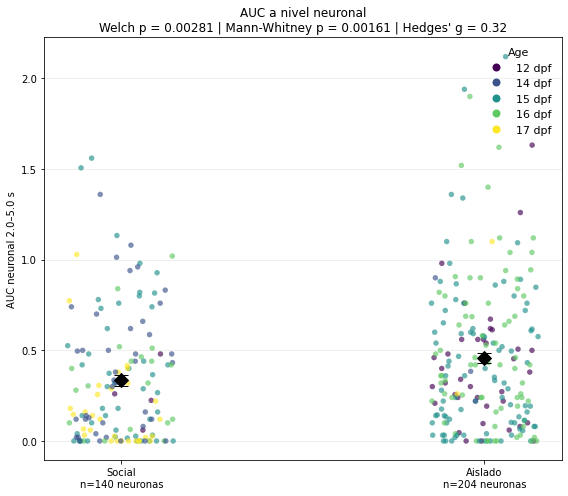

In [19]:
# ================================================================
# COMPARACIÓN DE AUC A NIVEL NEURONA 2026
#
# Cada punto = UNA NEURONA
# Color = EDAD
#
# NO se promedia por pez.
#
# AUC de cada neurona:
#   AUC trial → promedio entre trials válidos de esa neurona
#
# Comparación:
#   todas las neuronas Sociales vs todas las Aisladas
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.lines import Line2D


# ================================================================
# COLORES POR EDAD
# Mismos colores que en el gráfico de consistencia
# ================================================================

age_colors = {
    12: "#440154",   # violeta
    14: "#3b528b",   # azul
    15: "#21918c",   # verde/azulado
    16: "#5ec962",   # verde
    17: "#fde725",   # amarillo
}


# ================================================================
# DATOS
# ================================================================

df_social = df_auc_neurona.loc[
    df_auc_neurona["condicion"] == "Social"
].dropna(subset=["AUC_neurona", "edad"]).copy()

df_aislado = df_auc_neurona.loc[
    df_auc_neurona["condicion"] == "Aislado"
].dropna(subset=["AUC_neurona", "edad"]).copy()


# Vectores para estadística
social = df_social["AUC_neurona"].values
aislado = df_aislado["AUC_neurona"].values


# ================================================================
# ESTADÍSTICA DESCRIPTIVA
# ================================================================

print("================ AUC POR NEURONA ================\n")

print(
    f"Social:  {np.mean(social):.4f} ± {stats.sem(social):.4f} "
    f"(media ± SEM, n={len(social)} neuronas)"
)

print(
    f"Aislado: {np.mean(aislado):.4f} ± {stats.sem(aislado):.4f} "
    f"(media ± SEM, n={len(aislado)} neuronas)"
)

print(
    f"\nDiferencia Aislado - Social: "
    f"{np.mean(aislado) - np.mean(social):.4f}"
)


# ================================================================
# TEST 1 — WELCH
# ================================================================

welch = stats.ttest_ind(
    social,
    aislado,
    equal_var=False
)

print("\n================ WELCH T-TEST ================\n")

print(
    f"t = {welch.statistic:.3f}, "
    f"p = {welch.pvalue:.8g}"
)


# ================================================================
# TEST 2 — MANN-WHITNEY
# ================================================================

mw = stats.mannwhitneyu(
    social,
    aislado,
    alternative="two-sided"
)

print("\n================ MANN-WHITNEY ================\n")

print(
    f"U = {mw.statistic:.1f}, "
    f"p = {mw.pvalue:.8g}"
)


# ================================================================
# HEDGES' g
# ================================================================

def hedges_g(x, y):

    n1, n2 = len(x), len(y)
    s1, s2 = np.std(x, ddof=1), np.std(y, ddof=1)

    pooled = np.sqrt(
        ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) /
        (n1 + n2 - 2)
    )

    d = (np.mean(y) - np.mean(x)) / pooled
    correction = 1 - 3 / (4 * (n1 + n2) - 9)

    return correction * d


g = hedges_g(social, aislado)

print(f"\nHedges' g = {g:.3f}")


# ================================================================
# GRÁFICO
#
# Cada punto = AUC de una neurona
# Color = edad
# Diamante negro = media ± SEM
# ================================================================

fig, ax = plt.subplots(figsize=(8, 7))

rng = np.random.default_rng(42)


# ================================================================
# SOCIALES
# ================================================================

x = 0

for _, row in df_social.iterrows():

    edad = int(row["edad"])

    jitter = rng.uniform(-0.15, 0.15)

    ax.scatter(
        x + jitter,
        row["AUC_neurona"],
        color=age_colors[edad],
        alpha=0.65,
        s=30,
        edgecolors="none",
        zorder=2
    )


# Media ± SEM
ax.errorbar(
    x,
    np.mean(social),
    yerr=stats.sem(social),
    fmt="D",
    color="black",
    markersize=10,
    capsize=7,
    linewidth=2.5,
    zorder=5
)


# ================================================================
# AISLADAS
# ================================================================

x = 1

for _, row in df_aislado.iterrows():

    edad = int(row["edad"])

    jitter = rng.uniform(-0.15, 0.15)

    ax.scatter(
        x + jitter,
        row["AUC_neurona"],
        color=age_colors[edad],
        alpha=0.65,
        s=30,
        edgecolors="none",
        zorder=2
    )


# Media ± SEM
ax.errorbar(
    x,
    np.mean(aislado),
    yerr=stats.sem(aislado),
    fmt="D",
    color="black",
    markersize=10,
    capsize=7,
    linewidth=2.5,
    zorder=5
)


# ================================================================
# EJES
# ================================================================

ax.set_xticks([0, 1])

ax.set_xticklabels([
    f"Social\nn={len(social)} neuronas",
    f"Aislado\nn={len(aislado)} neuronas"
])

ax.set_ylabel(
    f"AUC neuronal {cola_inicio:.1f}–{cola_fin:.1f} s"
)

ax.set_title(
    "AUC a nivel neuronal\n"
    f"Welch p = {welch.pvalue:.3g} | "
    f"Mann-Whitney p = {mw.pvalue:.3g} | "
    f"Hedges' g = {g:.2f}"
)

ax.grid(
    axis="y",
    alpha=0.25
)


# ================================================================
# LEYENDA — EDAD
# ================================================================

age_handles = [

    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=age_colors[edad],
        markeredgecolor="none",
        markersize=8,
        label=f"{edad} dpf"
    )

    for edad in [12, 14, 15, 16, 17]
]

ax.legend(
    handles=age_handles,
    title="Age",
    frameon=False,
    loc="upper right",
    fontsize=11,
    title_fontsize=11
)


plt.tight_layout()
plt.show()

## AUC don Df/f

In [53]:
# ================================================================
# AUC DE ΔF/F DE LA COLA
#
# Selección de neuronas = actividad binaria
# Cálculo del AUC        = ΔF/F
#
# Jerarquía:
# trial → promedio por neurona → promedio por pez
# ================================================================

edad_minima = 12
consistencia_repeticion = 4

cola_inicio = 1
cola_fin = 5


# ================================================================
# FUNCIONES
# ================================================================

def calcular_auc(y, t):
    return np.trapezoid(y, t) if hasattr(np, "trapezoid") else np.trapz(y, t)


# ================================================================
# PROCESAMIENTO
# ================================================================

filas_trial_dff = []
filas_neurona_dff = []
filas_pez_dff = []

for fish_id, area in areas.items():

    aislado = getattr(area, "aislado", None)
    edad = getattr(area, "edad", np.nan)

    if edad is None or not np.isfinite(edad) or edad < edad_minima:
        continue

    if aislado not in [0, 1]:
        continue

    condicion = "Social" if aislado == 0 else "Aislado"


    # ------------------------------------------------------------
    # Neuronas consistentes
    # Se siguen seleccionando con actividad BINARIA
    # ------------------------------------------------------------

    active_mask = get_consistent_mask_original(area)

    if active_mask is None or not active_mask.any():
        continue

    consistent_indices = np.where(active_mask)[0]

    aucs_por_neurona = {
        n: [] for n in consistent_indices
    }

    av_trial_n = 0


    # ============================================================
    # TRIALS AV
    # ============================================================

    for tr in getattr(area, "trials_rea", []):

        if _get_condition(tr) != "AV":
            continue

        av_trial_n += 1


        # --------------------------------------------------------
        # ACTIVIDAD BINARIA
        # Sólo se usa para decidir si respondió
        # --------------------------------------------------------

        rb = getattr(tr, "roi_binaries_rea", None)

        if rb is None or region_key not in rb:
            continue

        B = (np.asarray(rb[region_key]) > 0).astype(int)


        # --------------------------------------------------------
        # ΔF/F
        # Se usa para calcular el AUC
        # --------------------------------------------------------

        rdff = getattr(tr, "roi_dffs_rea", None)

        if rdff is None or region_key not in rdff:
            continue

        D = np.asarray(
            rdff[region_key],
            dtype=float
        )


        # Comprobaciones
        if len(active_mask) != B.shape[0]:
            continue

        if D.shape[0] != B.shape[0]:
            continue


        # --------------------------------------------------------
        # TIEMPO
        # --------------------------------------------------------

        t, tr_fps = _trial_timebase(tr, fps)

        n_frames = min(
            B.shape[1],
            D.shape[1],
            len(t)
        )

        B = B[:, :n_frames]
        D = D[:, :n_frames]
        t = t[:n_frames]

        t_rel = t - stim_s

        stim_frame = int(round(stim_s * tr_fps))


        # --------------------------------------------------------
        # VENTANA ORIGINAL
        #
        # Define si la neurona respondió en este trial
        # --------------------------------------------------------

        win_idx = np.arange(
            stim_frame - frames_pre,
            stim_frame + frames_post + 1
        )

        win_idx = win_idx[
            (win_idx >= 0) &
            (win_idx < n_frames)
        ]

        if len(win_idx) == 0:
            continue


        # --------------------------------------------------------
        # VENTANA DEL AUC
        # --------------------------------------------------------

        mask_cola = (
            (t_rel >= cola_inicio) &
            (t_rel <= cola_fin)
        )

        if mask_cola.sum() < 2:
            continue

        t_cola = t_rel[mask_cola]


        # ========================================================
        # NEURONAS
        # ========================================================

        for neuron_idx in consistent_indices:

            # ----------------------------------------------------
            # ¿Respondió en ESTE trial?
            # Esto se sigue evaluando con la traza BINARIA
            # ----------------------------------------------------

            if B[neuron_idx, win_idx].sum() == 0:
                continue


            # ----------------------------------------------------
            # AUC DEL ΔF/F
            # ----------------------------------------------------

            dff_cola = D[
                neuron_idx,
                mask_cola
            ]

            # Evitar traces con NaN
            valid = (
                np.isfinite(dff_cola) &
                np.isfinite(t_cola)
            )

            if valid.sum() < 2:
                continue

            auc_trial = calcular_auc(
                dff_cola[valid],
                t_cola[valid]
            )


            # Guardar AUC del trial
            aucs_por_neurona[
                neuron_idx
            ].append(auc_trial)


            filas_trial_dff.append({
                "fish_id": fish_id,
                "edad": edad,
                "condicion": condicion,
                "neuron": neuron_idx,
                "trial": av_trial_n,
                "AUC_trial_dff": auc_trial
            })


    # ============================================================
    # NIVEL NEURONA
    #
    # Promedio de sus trials válidos
    # ============================================================

    aucs_neuronas_pez = []

    for neuron_idx, aucs_trials in aucs_por_neurona.items():

        if not aucs_trials:
            continue

        auc_neurona = np.mean(
            aucs_trials
        )

        aucs_neuronas_pez.append(
            auc_neurona
        )

        filas_neurona_dff.append({
            "fish_id": fish_id,
            "edad": edad,
            "condicion": condicion,
            "neuron": neuron_idx,
            "n_trials": len(aucs_trials),
            "AUC_neurona_dff": auc_neurona
        })


    if not aucs_neuronas_pez:
        continue


    # ============================================================
    # NIVEL PEZ
    #
    # Todas las neuronas pesan igual
    # ============================================================

    auc_pez = np.mean(
        aucs_neuronas_pez
    )

    filas_pez_dff.append({
        "fish_id": fish_id,
        "edad": edad,
        "condicion": condicion,
        "n_neuronas": len(aucs_neuronas_pez),
        "AUC_dff": auc_pez
    })


# ================================================================
# DATAFRAMES
# ================================================================

df_auc_trial_dff = pd.DataFrame(
    filas_trial_dff
)

df_auc_neurona_dff = pd.DataFrame(
    filas_neurona_dff
)

df_auc_pez_dff = pd.DataFrame(
    filas_pez_dff
)

print(
    "Jerarquía AUC ΔF/F: "
    "trial → promedio por neurona → promedio por pez"
)

display(df_auc_pez_dff)

Jerarquía AUC ΔF/F: trial → promedio por neurona → promedio por pez


,fish_id,edad,condicion,n_neuronas,AUC_dff
0,148-1,12.0,Social,3,0.391384
1,149-1,12.0,Aislado,12,0.863485
2,150-1,12.0,Social,1,0.283944
3,151-1,12.0,Aislado,25,1.258530
4,154-1,15.0,Social,4,0.203675
5,156-1,15.0,Social,1,0.277949
6,157-1,15.0,Aislado,36,0.758715
7,159-1,15.0,Social,13,0.493171
8,162-1,15.0,Aislado,17,0.661935
9,164-1,15.0,Aislado,3,0.921270


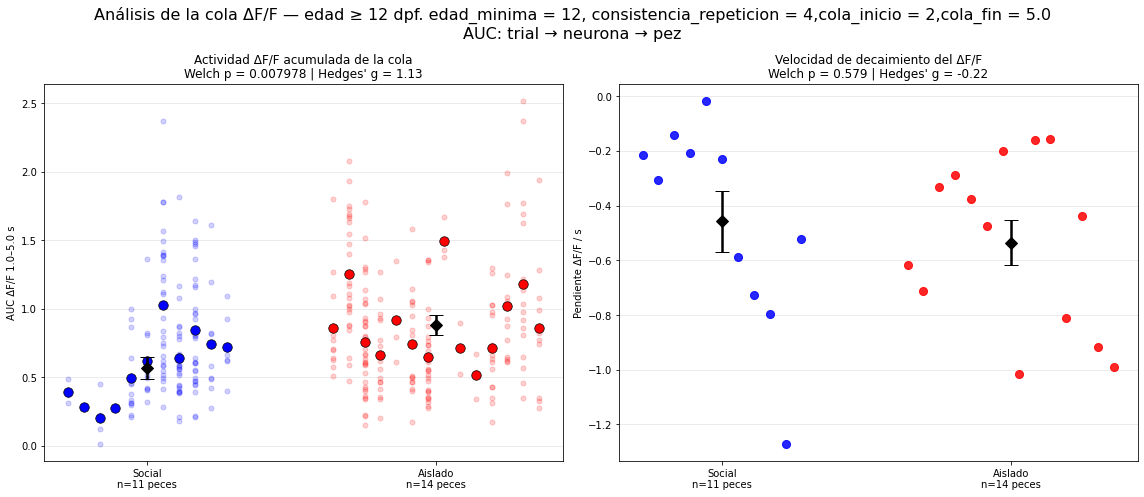

In [54]:
# ================================================================
# FIGURA RESUMEN — ΔF/F
#2026
# PANEL 1:
#   AUC del ΔF/F
#   punto claro = AUC de una neurona
#   punto grande = AUC promedio del pez
#   diamante negro = media ± SEM entre peces
#
# PANEL 2:
#   pendiente del ΔF/F entre cola_inicio y cola_fin
#   punto = un pez
#   diamante negro = media ± SEM
# ================================================================


# ================================================================
# CALCULAR PENDIENTE DEL ΔF/F POR PEZ
# ================================================================

pendientes_dff = []

for fish_id, area in areas.items():

    aislado = getattr(area, "aislado", None)
    edad = getattr(area, "edad", np.nan)

    if edad is None or not np.isfinite(edad) or edad < edad_minima:
        continue

    if aislado not in [0, 1]:
        continue

    condicion = "Social" if aislado == 0 else "Aislado"

    active_mask = get_consistent_mask_original(area)

    if active_mask is None or not active_mask.any():
        continue

    consistent_indices = np.where(active_mask)[0]

    perfiles_pez = []
    tiempos_pez = []


    for tr in getattr(area, "trials_rea", []):

        if _get_condition(tr) != "AV":
            continue

        rb = getattr(tr, "roi_binaries_rea", None)
        rdff = getattr(tr, "roi_dffs", None)

        if (
            rb is None or region_key not in rb or
            rdff is None or region_key not in rdff
        ):
            continue

        B = (np.asarray(rb[region_key]) > 0).astype(int)
        D = np.asarray(rdff[region_key], dtype=float)

        if len(active_mask) != B.shape[0]:
            continue

        if D.shape[0] != B.shape[0]:
            continue

        t, tr_fps = _trial_timebase(tr, fps)

        n_frames = min(
            B.shape[1],
            D.shape[1],
            len(t)
        )

        B = B[:, :n_frames]
        D = D[:, :n_frames]
        t = t[:n_frames]

        t_rel = t - stim_s
        stim_frame = int(round(stim_s * tr_fps))


        # Ventana original:
        # define si la neurona respondió en ESTE trial
        win_idx = np.arange(
            stim_frame - frames_pre,
            stim_frame + frames_post + 1
        )

        win_idx = win_idx[
            (win_idx >= 0) &
            (win_idx < n_frames)
        ]

        if len(win_idx) == 0:
            continue


        # Ventana para construir la curva
        plot_mask = (
            (t_rel >= -1) &
            (t_rel <= cola_fin)
        )

        t_plot = t_rel[plot_mask]


        for neuron_idx in consistent_indices:

            # Mismo criterio que para el AUC:
            # sólo trials donde esta neurona respondió
            if B[neuron_idx, win_idx].sum() == 0:
                continue

            perfil = D[
                neuron_idx,
                plot_mask
            ]

            perfiles_pez.append(perfil)
            tiempos_pez.append(t_plot)


    # ============================================================
    # CURVA PROMEDIO DEL PEZ
    # ============================================================

    pendiente = np.nan

    if perfiles_pez:

        min_len = min(map(len, perfiles_pez))

        perfiles_array = np.vstack([
            p[:min_len]
            for p in perfiles_pez
        ])

        t_pez = tiempos_pez[0][:min_len]

        curva_pez = np.nanmean(
            perfiles_array,
            axis=0
        )

        mask = (
            (t_pez >= cola_inicio) &
            (t_pez <= cola_fin) &
            np.isfinite(curva_pez)
        )

        if mask.sum() >= 2:

            pendiente = stats.linregress(
                t_pez[mask],
                curva_pez[mask]
            ).slope


    pendientes_dff.append({
        "fish_id": fish_id,
        "pendiente_dff": pendiente
    })


# ================================================================
# AGREGAR PENDIENTE A df_auc_pez_dff
# ================================================================

df_pendiente_dff = pd.DataFrame(
    pendientes_dff
)

df_auc_pez_dff = df_auc_pez_dff.drop(
    columns=["pendiente_dff"],
    errors="ignore"
).merge(
    df_pendiente_dff,
    on="fish_id",
    how="left"
)


# ================================================================
# ESTADÍSTICA
# ================================================================

def comparar_grupos_dff(variable):

    social = df_auc_pez_dff.loc[
        df_auc_pez_dff["condicion"] == "Social",
        variable
    ].dropna().values

    aislado = df_auc_pez_dff.loc[
        df_auc_pez_dff["condicion"] == "Aislado",
        variable
    ].dropna().values

    welch = stats.ttest_ind(
        social,
        aislado,
        equal_var=False
    )

    return {
        "social": social,
        "aislado": aislado,
        "welch": welch,
        "g": hedges_g(social, aislado)
    }


res_auc_dff = comparar_grupos_dff(
    "AUC_dff"
)

res_slope_dff = comparar_grupos_dff(
    "pendiente_dff"
)


# ================================================================
# FIGURA
# ================================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 7)
)

spacing = .055


# ================================================================
# PANEL 1 — AUC ΔF/F
# ================================================================

ax = axes[0]

for center, condicion, color in [
    (0, "Social", "blue"),
    (1, "Aislado", "red")
]:

    peces = (
        df_auc_pez_dff[
            df_auc_pez_dff["condicion"] == condicion
        ]
        .sort_values("fish_id")
        .reset_index(drop=True)
    )

    offsets = (
        np.arange(len(peces)) -
        (len(peces)-1)/2
    ) * spacing

    xs = center + offsets


    for x, (_, pez) in zip(
        xs,
        peces.iterrows()
    ):

        aucs_n = df_auc_neurona_dff.loc[
            df_auc_neurona_dff["fish_id"] == pez["fish_id"],
            "AUC_neurona_dff"
        ].dropna().values


        # Puntos claros = neuronas
        ax.scatter(
            np.full(len(aucs_n), x),
            aucs_n,
            color=color,
            alpha=.18,
            s=25,
            zorder=2
        )


        # Punto grande = pez
        ax.scatter(
            x,
            pez["AUC_dff"],
            color=color,
            edgecolor="black",
            linewidth=.7,
            s=90,
            zorder=4
        )


    vals = peces[
        "AUC_dff"
    ].dropna().values


    # Media ± SEM
    ax.errorbar(
        center,
        vals.mean(),
        yerr=stats.sem(vals),
        fmt="D",
        color="black",
        markersize=9,
        capsize=7,
        linewidth=2.5,
        zorder=6
    )


ax.set_xticks([0, 1])

ax.set_xticklabels([
    f"Social\nn={len(res_auc_dff['social'])} peces",
    f"Aislado\nn={len(res_auc_dff['aislado'])} peces"
])

ax.set_ylabel(
    f"AUC ΔF/F {cola_inicio:.1f}–{cola_fin:.1f} s"
)

ax.set_title(
    "Actividad ΔF/F acumulada de la cola\n"
    f"Welch p = {res_auc_dff['welch'].pvalue:.4g} | "
    f"Hedges' g = {res_auc_dff['g']:.2f}"
)

ax.grid(
    axis="y",
    alpha=.3
)


# ================================================================
# PANEL 2 — PENDIENTE ΔF/F
# ================================================================

ax = axes[1]

for center, condicion, color in [
    (0, "Social", "blue"),
    (1, "Aislado", "red")
]:

    peces = (
        df_auc_pez_dff[
            df_auc_pez_dff["condicion"] == condicion
        ]
        .sort_values("fish_id")
        .reset_index(drop=True)
    )

    offsets = (
        np.arange(len(peces)) -
        (len(peces)-1)/2
    ) * spacing

    xs = center + offsets

    vals = peces[
        "pendiente_dff"
    ].values


    # Peces individuales
    ax.scatter(
        xs,
        vals,
        color=color,
        alpha=.85,
        s=65,
        zorder=3
    )


    vals = vals[
        np.isfinite(vals)
    ]


    # Media ± SEM
    ax.errorbar(
        center,
        vals.mean(),
        yerr=stats.sem(vals),
        fmt="D",
        color="black",
        markersize=9,
        capsize=7,
        linewidth=2.5,
        zorder=5
    )


ax.set_xticks([0, 1])

ax.set_xticklabels([
    f"Social\nn={len(res_slope_dff['social'])} peces",
    f"Aislado\nn={len(res_slope_dff['aislado'])} peces"
])

ax.set_ylabel(
    "Pendiente ΔF/F / s"
)

ax.set_title(
    "Velocidad de decaimiento del ΔF/F\n"
    f"Welch p = {res_slope_dff['welch'].pvalue:.4g} | "
    f"Hedges' g = {res_slope_dff['g']:.2f}"
)

ax.grid(
    axis="y",
    alpha=.3
)


# ================================================================
# TÍTULO GENERAL
# ================================================================

fig.suptitle(
    f"Análisis de la cola ΔF/F — edad ≥ {edad_minima} dpf. edad_minima = 12, consistencia_repeticion = 4,cola_inicio = 2,cola_fin = 5.0\n"
    "AUC: trial → neurona → pez",
    fontsize=16
)

plt.tight_layout()
plt.show()

## s

In [55]:
# ================================================================
# FILTRO — MÍNIMO DE NEURONAS VÁLIDAS POR PEZ
# ================================================================

min_neuronas_por_pez = 2

# ------------------------------------------------
# Contar neuronas con AUC válido por pez
# ------------------------------------------------

conteo_neuronas = (
    df_auc_neurona_dff
    .dropna(subset=["AUC_neurona_dff"])
    .groupby("fish_id")
    .size()
    .rename("n_neuronas_validas")
    .reset_index()
)


# ------------------------------------------------
# Agregar conteo al dataframe por pez
# ------------------------------------------------

df_auc_pez_dff = (
    df_auc_pez_dff
    .drop(columns=["n_neuronas_validas"], errors="ignore")
    .merge(
        conteo_neuronas,
        on="fish_id",
        how="left"
    )
)

df_auc_pez_dff["n_neuronas_validas"] = (
    df_auc_pez_dff["n_neuronas_validas"]
    .fillna(0)
    .astype(int)
)


# ================================================================
# MOSTRAR QUÉ PECES SE EXCLUYEN
# ================================================================

peces_excluidos = df_auc_pez_dff[
    df_auc_pez_dff["n_neuronas_validas"] < min_neuronas_por_pez
].copy()

print(
    f"\n================ FILTRO ≥ {min_neuronas_por_pez} NEURONAS ================\n"
)

print(
    f"Peces antes del filtro: {len(df_auc_pez_dff)}"
)

print(
    f"Peces excluidos: {len(peces_excluidos)}"
)

if len(peces_excluidos) > 0:

    print("\nPeces excluidos:")

    print(
        peces_excluidos[
            [
                "fish_id",
                "condicion",
                "n_neuronas_validas"
            ]
        ].to_string(index=False)
    )


# ================================================================
# APLICAR FILTRO
# ================================================================

df_auc_pez_dff = df_auc_pez_dff[
    df_auc_pez_dff["n_neuronas_validas"] >= min_neuronas_por_pez
].copy()


print(
    f"\nPeces después del filtro: {len(df_auc_pez_dff)}"
)

print("\nPor condición:")

print(
    df_auc_pez_dff
    .groupby("condicion")
    .size()
)


================ FILTRO ≥ 2 NEURONAS ================

Peces antes del filtro: 25
Peces excluidos: 2

Peces excluidos:
fish_id condicion  n_neuronas_validas
  150-1    Social                   1
  156-1    Social                   1

Peces después del filtro: 23

Por condición:
condicion
Aislado    14
Social      9
dtype: int64



FILTRO: >= 2 NEURONAS VÁLIDAS POR PEZ

Peces antes del filtro: 23
Peces excluidos: 0

Peces después del filtro: 23

Peces por condición:
condicion
Aislado    14
Social      9
dtype: int64


AUC ΔF/F — PECES CON >= 2 NEURONAS

Social: 0.6333 ± 0.0823 (media ± SEM, n=9 peces)
Aislado: 0.8827 ± 0.0725 (media ± SEM, n=14 peces)

Diferencia Aislado - Social: 0.2494

Welch: t = -2.274, p = 0.035153169
Mann-Whitney: U = 31.0, p = 0.047220904
Hedges' g = 0.917


PENDIENTE ΔF/F — PECES CON >= 2 NEURONAS

Social: -0.5011 ± 0.1323 (media ± SEM, n=9 peces)
Aislado: -0.5348 ± 0.0822 (media ± SEM, n=14 peces)

Diferencia Aislado - Social: -0.0337

Welch: t = 0.216, p = 0.83181057
Mann-Whitney: U = 70.0, p = 0.68220101
Hedges' g = -0.094


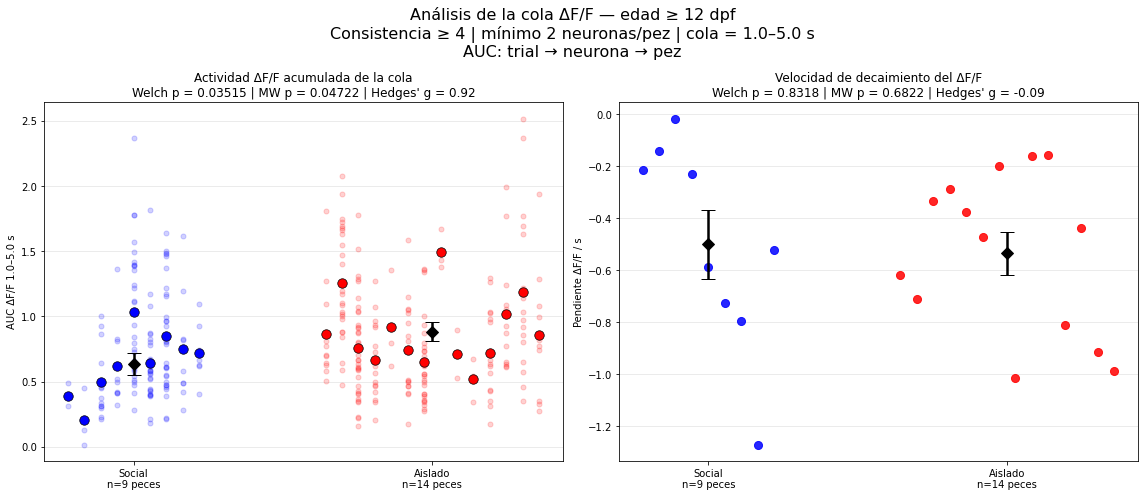

In [56]:
# ================================================================
# FIGURA RESUMEN ΔF/F — SOLO PECES CON >= 2 NEURONAS VÁLIDAS
# 2026
#
# PANEL 1:
#   AUC del ΔF/F
#   punto claro = AUC de una neurona
#   punto grande = AUC promedio del pez
#   diamante negro = media ± SEM entre peces
#
# PANEL 2:
#   pendiente del ΔF/F entre cola_inicio y cola_fin
#   punto = un pez
#   diamante negro = media ± SEM
#
# FILTRO:
#   Solo peces con >= 2 neuronas con AUC_neurona_dff válido
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# ================================================================
# CONFIGURACIÓN
# ================================================================



# ================================================================
# 1. CONTAR NEURONAS VÁLIDAS POR PEZ
# ================================================================

conteo_neuronas = (
    df_auc_neurona_dff
    .dropna(subset=["AUC_neurona_dff"])
    .groupby("fish_id")
    .size()
    .rename("n_neuronas_validas")
    .reset_index()
)


# ================================================================
# 2. CREAR DATAFRAME FILTRADO
#
# IMPORTANTE:
# No modificamos df_auc_pez_dff original.
# ================================================================

df_auc_pez_dff_filtrado = (
    df_auc_pez_dff
    .drop(columns=["n_neuronas_validas"], errors="ignore")
    .merge(
        conteo_neuronas,
        on="fish_id",
        how="left"
    )
)

df_auc_pez_dff_filtrado["n_neuronas_validas"] = (
    df_auc_pez_dff_filtrado["n_neuronas_validas"]
    .fillna(0)
    .astype(int)
)


# ================================================================
# 3. MOSTRAR PECES EXCLUIDOS
# ================================================================

peces_excluidos = df_auc_pez_dff_filtrado[
    df_auc_pez_dff_filtrado["n_neuronas_validas"] < min_neuronas_por_pez
].copy()


print(
    "\n============================================================"
)
print(
    f"FILTRO: >= {min_neuronas_por_pez} NEURONAS VÁLIDAS POR PEZ"
)
print(
    "============================================================\n"
)

print(
    f"Peces antes del filtro: "
    f"{len(df_auc_pez_dff_filtrado)}"
)

print(
    f"Peces excluidos: "
    f"{len(peces_excluidos)}"
)


if len(peces_excluidos) > 0:

    print("\nPeces excluidos:")

    columnas_mostrar = [
        c for c in
        [
            "fish_id",
            "condicion",
            "edad",
            "n_neuronas_validas"
        ]
        if c in peces_excluidos.columns
    ]

    print(
        peces_excluidos[
            columnas_mostrar
        ].to_string(index=False)
    )


# ================================================================
# 4. APLICAR FILTRO
# ================================================================

df_auc_pez_dff_filtrado = (
    df_auc_pez_dff_filtrado[
        df_auc_pez_dff_filtrado["n_neuronas_validas"]
        >= min_neuronas_por_pez
    ]
    .copy()
)


print(
    f"\nPeces después del filtro: "
    f"{len(df_auc_pez_dff_filtrado)}"
)

print("\nPeces por condición:")

print(
    df_auc_pez_dff_filtrado
    .groupby("condicion")
    .size()
)


# ================================================================
# 5. HEDGES' g
# ================================================================

def hedges_g(x, y):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    n1 = len(x)
    n2 = len(y)

    s1 = np.std(x, ddof=1)
    s2 = np.std(y, ddof=1)

    pooled = np.sqrt(
        (
            (n1 - 1) * s1**2 +
            (n2 - 1) * s2**2
        )
        /
        (n1 + n2 - 2)
    )

    d = (
        np.mean(y) - np.mean(x)
    ) / pooled

    correction = (
        1 -
        3 / (4 * (n1 + n2) - 9)
    )

    return correction * d


# ================================================================
# 6. FUNCIÓN PARA COMPARAR GRUPOS
# ================================================================

def comparar_grupos_dff_filtrado(variable):

    social = (
        df_auc_pez_dff_filtrado.loc[
            df_auc_pez_dff_filtrado["condicion"] == "Social",
            variable
        ]
        .dropna()
        .values
    )

    aislado = (
        df_auc_pez_dff_filtrado.loc[
            df_auc_pez_dff_filtrado["condicion"] == "Aislado",
            variable
        ]
        .dropna()
        .values
    )

    # Welch
    welch = stats.ttest_ind(
        social,
        aislado,
        equal_var=False
    )

    # Mann-Whitney
    mw = stats.mannwhitneyu(
        social,
        aislado,
        alternative="two-sided"
    )

    # Hedges' g
    g = hedges_g(
        social,
        aislado
    )

    return {
        "social": social,
        "aislado": aislado,
        "welch": welch,
        "mw": mw,
        "g": g
    }


# ================================================================
# 7. ESTADÍSTICA — AUC
# ================================================================

res_auc_dff_filtrado = comparar_grupos_dff_filtrado(
    "AUC_dff"
)


print(
    "\n\n============================================================"
)
print(
    "AUC ΔF/F — PECES CON >= 2 NEURONAS"
)
print(
    "============================================================\n"
)


social = res_auc_dff_filtrado["social"]
aislado = res_auc_dff_filtrado["aislado"]


print(
    f"Social: "
    f"{np.mean(social):.4f} ± {stats.sem(social):.4f} "
    f"(media ± SEM, n={len(social)} peces)"
)

print(
    f"Aislado: "
    f"{np.mean(aislado):.4f} ± {stats.sem(aislado):.4f} "
    f"(media ± SEM, n={len(aislado)} peces)"
)

print(
    f"\nDiferencia Aislado - Social: "
    f"{np.mean(aislado) - np.mean(social):.4f}"
)

print(
    f"\nWelch: "
    f"t = {res_auc_dff_filtrado['welch'].statistic:.3f}, "
    f"p = {res_auc_dff_filtrado['welch'].pvalue:.8g}"
)

print(
    f"Mann-Whitney: "
    f"U = {res_auc_dff_filtrado['mw'].statistic:.1f}, "
    f"p = {res_auc_dff_filtrado['mw'].pvalue:.8g}"
)

print(
    f"Hedges' g = "
    f"{res_auc_dff_filtrado['g']:.3f}"
)


# ================================================================
# 8. ESTADÍSTICA — PENDIENTE
# ================================================================

res_slope_dff_filtrado = comparar_grupos_dff_filtrado(
    "pendiente_dff"
)


print(
    "\n\n============================================================"
)
print(
    "PENDIENTE ΔF/F — PECES CON >= 2 NEURONAS"
)
print(
    "============================================================\n"
)


social = res_slope_dff_filtrado["social"]
aislado = res_slope_dff_filtrado["aislado"]


print(
    f"Social: "
    f"{np.mean(social):.4f} ± {stats.sem(social):.4f} "
    f"(media ± SEM, n={len(social)} peces)"
)

print(
    f"Aislado: "
    f"{np.mean(aislado):.4f} ± {stats.sem(aislado):.4f} "
    f"(media ± SEM, n={len(aislado)} peces)"
)

print(
    f"\nDiferencia Aislado - Social: "
    f"{np.mean(aislado) - np.mean(social):.4f}"
)

print(
    f"\nWelch: "
    f"t = {res_slope_dff_filtrado['welch'].statistic:.3f}, "
    f"p = {res_slope_dff_filtrado['welch'].pvalue:.8g}"
)

print(
    f"Mann-Whitney: "
    f"U = {res_slope_dff_filtrado['mw'].statistic:.1f}, "
    f"p = {res_slope_dff_filtrado['mw'].pvalue:.8g}"
)

print(
    f"Hedges' g = "
    f"{res_slope_dff_filtrado['g']:.3f}"
)


# ================================================================
# 9. FIGURA
# ================================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 7)
)

spacing = .055


# ================================================================
# PANEL 1 — AUC ΔF/F
# ================================================================

ax = axes[0]


for center, condicion, color in [
    (0, "Social", "blue"),
    (1, "Aislado", "red")
]:

    peces = (
        df_auc_pez_dff_filtrado[
            df_auc_pez_dff_filtrado["condicion"] == condicion
        ]
        .sort_values("fish_id")
        .reset_index(drop=True)
    )


    offsets = (
        np.arange(len(peces)) -
        (len(peces) - 1) / 2
    ) * spacing

    xs = center + offsets


    # ------------------------------------------------------------
    # Cada pez
    # ------------------------------------------------------------

    for x, (_, pez) in zip(
        xs,
        peces.iterrows()
    ):

        # Neuronas de ESTE pez
        aucs_n = (
            df_auc_neurona_dff.loc[
                df_auc_neurona_dff["fish_id"] == pez["fish_id"],
                "AUC_neurona_dff"
            ]
            .dropna()
            .values
        )


        # --------------------------------------------------------
        # Puntos claros = neuronas
        # --------------------------------------------------------

        ax.scatter(
            np.full(len(aucs_n), x),
            aucs_n,
            color=color,
            alpha=.18,
            s=25,
            zorder=2
        )


        # --------------------------------------------------------
        # Punto grande = promedio del pez
        # --------------------------------------------------------

        ax.scatter(
            x,
            pez["AUC_dff"],
            color=color,
            edgecolor="black",
            linewidth=.7,
            s=90,
            zorder=4
        )


    # ------------------------------------------------------------
    # Media ± SEM entre peces
    # ------------------------------------------------------------

    vals = (
        peces["AUC_dff"]
        .dropna()
        .values
    )

    ax.errorbar(
        center,
        vals.mean(),
        yerr=stats.sem(vals),
        fmt="D",
        color="black",
        markersize=9,
        capsize=7,
        linewidth=2.5,
        zorder=6
    )


ax.set_xticks([0, 1])

ax.set_xticklabels([
    (
        f"Social\n"
        f"n={len(res_auc_dff_filtrado['social'])} peces"
    ),
    (
        f"Aislado\n"
        f"n={len(res_auc_dff_filtrado['aislado'])} peces"
    )
])

ax.set_ylabel(
    f"AUC ΔF/F {cola_inicio:.1f}–{cola_fin:.1f} s"
)

ax.set_title(
    "Actividad ΔF/F acumulada de la cola\n"
    f"Welch p = {res_auc_dff_filtrado['welch'].pvalue:.4g} | "
    f"MW p = {res_auc_dff_filtrado['mw'].pvalue:.4g} | "
    f"Hedges' g = {res_auc_dff_filtrado['g']:.2f}"
)

ax.grid(
    axis="y",
    alpha=.3
)


# ================================================================
# PANEL 2 — PENDIENTE ΔF/F
# ================================================================

ax = axes[1]


for center, condicion, color in [
    (0, "Social", "blue"),
    (1, "Aislado", "red")
]:

    peces = (
        df_auc_pez_dff_filtrado[
            df_auc_pez_dff_filtrado["condicion"] == condicion
        ]
        .sort_values("fish_id")
        .reset_index(drop=True)
    )


    offsets = (
        np.arange(len(peces)) -
        (len(peces) - 1) / 2
    ) * spacing

    xs = center + offsets

    vals = peces[
        "pendiente_dff"
    ].values


    # ------------------------------------------------------------
    # Peces individuales
    # ------------------------------------------------------------

    mask_validos = np.isfinite(vals)

    ax.scatter(
        xs[mask_validos],
        vals[mask_validos],
        color=color,
        alpha=.85,
        s=65,
        zorder=3
    )


    # ------------------------------------------------------------
    # Media ± SEM
    # ------------------------------------------------------------

    vals_validos = vals[
        mask_validos
    ]

    ax.errorbar(
        center,
        vals_validos.mean(),
        yerr=stats.sem(vals_validos),
        fmt="D",
        color="black",
        markersize=9,
        capsize=7,
        linewidth=2.5,
        zorder=5
    )


ax.set_xticks([0, 1])

ax.set_xticklabels([
    (
        f"Social\n"
        f"n={len(res_slope_dff_filtrado['social'])} peces"
    ),
    (
        f"Aislado\n"
        f"n={len(res_slope_dff_filtrado['aislado'])} peces"
    )
])

ax.set_ylabel(
    "Pendiente ΔF/F / s"
)

ax.set_title(
    "Velocidad de decaimiento del ΔF/F\n"
    f"Welch p = {res_slope_dff_filtrado['welch'].pvalue:.4g} | "
    f"MW p = {res_slope_dff_filtrado['mw'].pvalue:.4g} | "
    f"Hedges' g = {res_slope_dff_filtrado['g']:.2f}"
)

ax.grid(
    axis="y",
    alpha=.3
)


# ================================================================
# TÍTULO GENERAL
# ================================================================

fig.suptitle(
    f"Análisis de la cola ΔF/F — edad ≥ {edad_minima} dpf\n"
    f"Consistencia ≥ {consistencia_repeticion} | "
    f"mínimo {min_neuronas_por_pez} neuronas/pez | "
    f"cola = {cola_inicio:.1f}–{cola_fin:.1f} s\n"
    "AUC: trial → neurona → pez",
    fontsize=16
)


plt.tight_layout()
plt.show()

================ AUC ΔF/F POR NEURONA ================

Social:  0.7419 ± 0.0356 (media ± SEM, n=140 neuronas)
Aislado: 0.8619 ± 0.0315 (media ± SEM, n=204 neuronas)

Diferencia Aislado - Social: 0.1200

================ WELCH T-TEST ================

t = -2.526, p = 0.012046773

================ MANN-WHITNEY ================

U = 11817.0, p = 0.0065766385

Hedges' g = 0.273


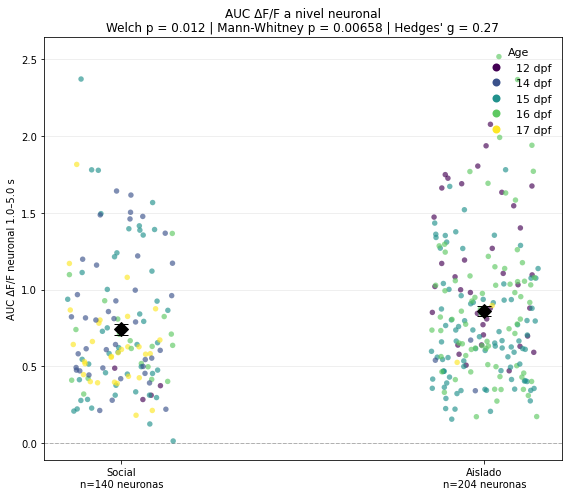

In [57]:
# ================================================================
# COMPARACIÓN DE AUC ΔF/F A NIVEL NEURONA — 2026
#
# Cada punto = UNA NEURONA
# Color = EDAD
#
# NO se promedia por pez para esta comparación.
#
# AUC de cada neurona:
#   AUC ΔF/F por trial válido
#       ↓
#   promedio entre trials válidos de esa neurona
#
# Comparación:
#   todas las neuronas Sociales vs todas las Aisladas
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.lines import Line2D


# ================================================================
# COLORES POR EDAD
# ================================================================

age_colors = {
    12: "#440154",   # violeta
    14: "#3b528b",   # azul
    15: "#21918c",   # verde/azulado
    16: "#5ec962",   # verde
    17: "#fde725",   # amarillo
}


# ================================================================
# DATOS
# ================================================================

df_social_dff = df_auc_neurona_dff.loc[
    df_auc_neurona_dff["condicion"] == "Social"
].dropna(
    subset=["AUC_neurona_dff", "edad"]
).copy()


df_aislado_dff = df_auc_neurona_dff.loc[
    df_auc_neurona_dff["condicion"] == "Aislado"
].dropna(
    subset=["AUC_neurona_dff", "edad"]
).copy()


# Vectores para estadística
social = df_social_dff[
    "AUC_neurona_dff"
].values

aislado = df_aislado_dff[
    "AUC_neurona_dff"
].values


# ================================================================
# ESTADÍSTICA DESCRIPTIVA
# ================================================================

print(
    "================ AUC ΔF/F POR NEURONA ================\n"
)

print(
    f"Social:  "
    f"{np.mean(social):.4f} ± {stats.sem(social):.4f} "
    f"(media ± SEM, n={len(social)} neuronas)"
)

print(
    f"Aislado: "
    f"{np.mean(aislado):.4f} ± {stats.sem(aislado):.4f} "
    f"(media ± SEM, n={len(aislado)} neuronas)"
)

print(
    f"\nDiferencia Aislado - Social: "
    f"{np.mean(aislado) - np.mean(social):.4f}"
)


# ================================================================
# TEST 1 — WELCH
# ================================================================

welch = stats.ttest_ind(
    social,
    aislado,
    equal_var=False
)

print(
    "\n================ WELCH T-TEST ================\n"
)

print(
    f"t = {welch.statistic:.3f}, "
    f"p = {welch.pvalue:.8g}"
)


# ================================================================
# TEST 2 — MANN-WHITNEY
# ================================================================

mw = stats.mannwhitneyu(
    social,
    aislado,
    alternative="two-sided"
)

print(
    "\n================ MANN-WHITNEY ================\n"
)

print(
    f"U = {mw.statistic:.1f}, "
    f"p = {mw.pvalue:.8g}"
)


# ================================================================
# HEDGES' g
# ================================================================

def hedges_g(x, y):

    n1, n2 = len(x), len(y)

    s1 = np.std(
        x,
        ddof=1
    )

    s2 = np.std(
        y,
        ddof=1
    )

    pooled = np.sqrt(
        (
            (n1 - 1) * s1**2 +
            (n2 - 1) * s2**2
        )
        /
        (n1 + n2 - 2)
    )

    # Positivo = Aislado > Social
    d = (
        np.mean(y) -
        np.mean(x)
    ) / pooled

    correction = (
        1 -
        3 / (4 * (n1 + n2) - 9)
    )

    return correction * d


g = hedges_g(
    social,
    aislado
)

print(
    f"\nHedges' g = {g:.3f}"
)


# ================================================================
# GRÁFICO
#
# Cada punto = AUC ΔF/F de una neurona
# Color = edad
# Diamante negro = media ± SEM
# ================================================================

fig, ax = plt.subplots(
    figsize=(8, 7)
)

# Jitter reproducible
rng = np.random.default_rng(42)


# ================================================================
# SOCIALES
# ================================================================

x = 0

for _, row in df_social_dff.iterrows():

    edad = int(
        row["edad"]
    )

    jitter = rng.uniform(
        -0.15,
        0.15
    )

    ax.scatter(
        x + jitter,
        row["AUC_neurona_dff"],

        color=age_colors[edad],

        alpha=0.65,
        s=30,

        edgecolors="none",

        zorder=2
    )


# ------------------------------------------------
# Media ± SEM — Social
# ------------------------------------------------

ax.errorbar(
    x,

    np.mean(social),

    yerr=stats.sem(
        social
    ),

    fmt="D",

    color="black",

    markersize=10,

    capsize=7,

    linewidth=2.5,

    zorder=5
)


# ================================================================
# AISLADAS
# ================================================================

x = 1

for _, row in df_aislado_dff.iterrows():

    edad = int(
        row["edad"]
    )

    jitter = rng.uniform(
        -0.15,
        0.15
    )

    ax.scatter(
        x + jitter,
        row["AUC_neurona_dff"],

        color=age_colors[edad],

        alpha=0.65,
        s=30,

        edgecolors="none",

        zorder=2
    )


# ------------------------------------------------
# Media ± SEM — Aislado
# ------------------------------------------------

ax.errorbar(
    x,

    np.mean(aislado),

    yerr=stats.sem(
        aislado
    ),

    fmt="D",

    color="black",

    markersize=10,

    capsize=7,

    linewidth=2.5,

    zorder=5
)


# ================================================================
# EJES
# ================================================================

ax.set_xticks(
    [0, 1]
)

ax.set_xticklabels([
    f"Social\nn={len(social)} neuronas",
    f"Aislado\nn={len(aislado)} neuronas"
])


ax.set_ylabel(
    f"AUC ΔF/F neuronal "
    f"{cola_inicio:.1f}–{cola_fin:.1f} s"
)


# Línea en AUC = 0
ax.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.6,
    zorder=1
)


ax.set_title(
    "AUC ΔF/F a nivel neuronal\n"
    f"Welch p = {welch.pvalue:.3g} | "
    f"Mann-Whitney p = {mw.pvalue:.3g} | "
    f"Hedges' g = {g:.2f}"
)


ax.grid(
    axis="y",
    alpha=0.25
)


# ================================================================
# LEYENDA — EDAD
# ================================================================

age_handles = [

    Line2D(
        [0], [0],

        marker="o",

        color="none",

        markerfacecolor=age_colors[edad],

        markeredgecolor="none",

        markersize=8,

        label=f"{edad} dpf"
    )

    for edad in [
        12,
        14,
        15,
        16,
        17
    ]
]


ax.legend(
    handles=age_handles,

    title="Age",

    frameon=False,

    loc="upper right",

    fontsize=11,

    title_fontsize=11
)


plt.tight_layout()
plt.show()

Neuronas sociales: 140
Neuronas aisladas: 204


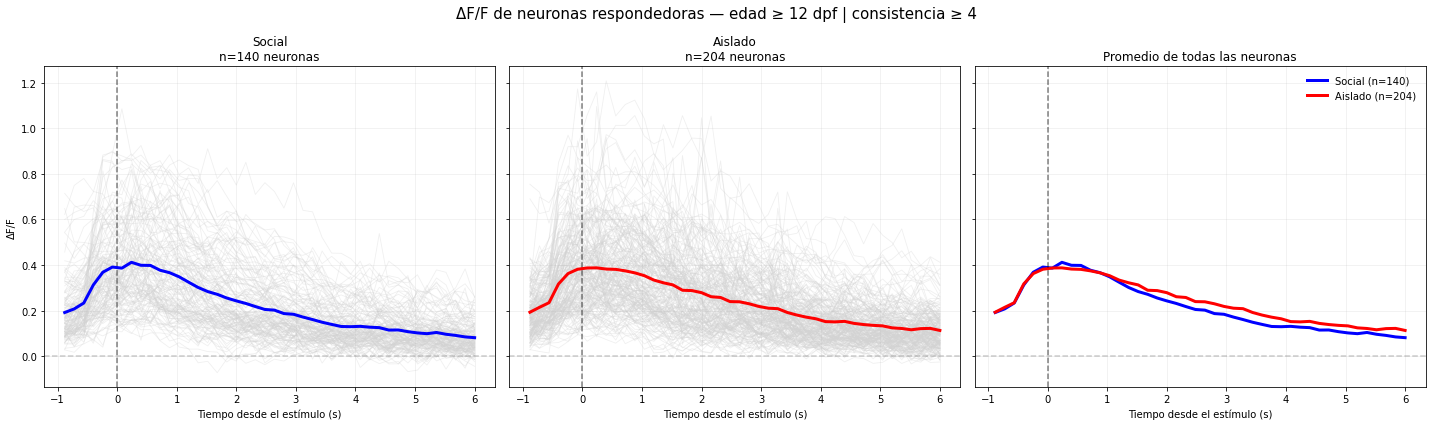

In [58]:
# ================================================================
# ΔF/F PROMEDIO DE NEURONAS QUE RESPONDIERON AL ESTÍMULO
# 2026
#
# PANEL 1:
#   Sociales
#   gris = curva promedio de cada neurona
#   azul = promedio de todas las neuronas sociales
#
# PANEL 2:
#   Aislados
#   gris = curva promedio de cada neurona
#   rojo = promedio de todas las neuronas aisladas
#
# PANEL 3:
#   promedio Social vs Aislado
#
# LÓGICA:
#   - sólo trials AV
#   - sólo neuronas consistentes
#   - sólo trials donde ESA neurona respondió
#   - trial → promedio por neurona
#   - neurona → promedio por condición
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ================================================================
# CONFIGURACIÓN
# ================================================================

t_inicio_plot = -1
t_fin_plot = 6

colores = {
    "Social": "blue",
    "Aislado": "red"
}


# ================================================================
# GUARDAR CURVAS DE CADA NEURONA
# ================================================================

curvas_neuronas = {
    "Social": [],
    "Aislado": []
}

tiempos_neuronas = {
    "Social": [],
    "Aislado": []
}


# ================================================================
# RECORRER PECES
# ================================================================

for fish_id, area in areas.items():

    aislado = getattr(
        area,
        "aislado",
        None
    )

    edad = getattr(
        area,
        "edad",
        np.nan
    )


    # ------------------------------------------------------------
    # Filtro de edad
    # ------------------------------------------------------------

    if (
        edad is None or
        not np.isfinite(edad) or
        edad < edad_minima
    ):
        continue


    # ------------------------------------------------------------
    # Condición social
    # ------------------------------------------------------------

    if aislado not in [0, 1]:
        continue

    condicion = (
        "Social"
        if aislado == 0
        else "Aislado"
    )


    # ============================================================
    # NEURONAS CONSISTENTES
    # ============================================================

    active_mask = get_consistent_mask_original(
        area
    )

    if (
        active_mask is None or
        not active_mask.any()
    ):
        continue


    consistent_indices = np.where(
        active_mask
    )[0]


    # ------------------------------------------------------------
    # Para cada neurona guardaremos sus trials válidos
    # ------------------------------------------------------------

    trials_por_neurona = {
        neuron_idx: []
        for neuron_idx in consistent_indices
    }

    tiempos_por_neurona = {
        neuron_idx: []
        for neuron_idx in consistent_indices
    }


    # ============================================================
    # RECORRER TRIALS AV
    # ============================================================

    for tr in getattr(
        area,
        "trials_rea",
        []
    ):

        if _get_condition(tr) != "AV":
            continue


        # --------------------------------------------------------
        # Actividad binaria
        # --------------------------------------------------------

        rb = getattr(
            tr,
            "roi_binaries_rea",
            None
        )

        if (
            rb is None or
            region_key not in rb
        ):
            continue

        B = (
            np.asarray(
                rb[region_key]
            ) > 0
        ).astype(int)


        # --------------------------------------------------------
        # ΔF/F
        # --------------------------------------------------------

        rdff = getattr(
            tr,
            "roi_dffs_rea",
            None
        )

        if (
            rdff is None or
            region_key not in rdff
        ):
            continue

        D = np.asarray(
            rdff[region_key],
            dtype=float
        )


        # --------------------------------------------------------
        # Comprobaciones
        # --------------------------------------------------------

        if len(active_mask) != B.shape[0]:
            continue

        if D.shape[0] != B.shape[0]:
            continue


        # ========================================================
        # TIEMPO
        # ========================================================

        t, tr_fps = _trial_timebase(
            tr,
            fps
        )

        n_frames = min(
            B.shape[1],
            D.shape[1],
            len(t)
        )

        B = B[:, :n_frames]
        D = D[:, :n_frames]
        t = t[:n_frames]

        t_rel = t - stim_s

        stim_frame = int(
            round(
                stim_s * tr_fps
            )
        )


        # ========================================================
        # VENTANA ORIGINAL
        #
        # Se usa para decidir si la neurona respondió
        # en ESTE trial
        # ========================================================

        win_idx = np.arange(
            stim_frame - frames_pre,
            stim_frame + frames_post + 1
        )

        win_idx = win_idx[
            (win_idx >= 0) &
            (win_idx < n_frames)
        ]

        if len(win_idx) == 0:
            continue


        # ========================================================
        # VENTANA PARA GRAFICAR
        # ========================================================

        plot_mask = (
            (t_rel >= t_inicio_plot) &
            (t_rel <= t_fin_plot)
        )

        if plot_mask.sum() < 2:
            continue

        t_plot = t_rel[
            plot_mask
        ]


        # ========================================================
        # NEURONAS
        # ========================================================

        for neuron_idx in consistent_indices:

            # ----------------------------------------------------
            # ¿Respondió esta neurona en ESTE trial?
            # ----------------------------------------------------

            if (
                B[
                    neuron_idx,
                    win_idx
                ].sum()
                == 0
            ):
                continue


            # ----------------------------------------------------
            # ΔF/F de esta neurona en este trial
            # ----------------------------------------------------

            perfil = D[
                neuron_idx,
                plot_mask
            ]


            trials_por_neurona[
                neuron_idx
            ].append(
                perfil
            )

            tiempos_por_neurona[
                neuron_idx
            ].append(
                t_plot
            )


    # ============================================================
    # PROMEDIO DE TRIALS DE CADA NEURONA
    #
    # Cada neurona queda representada por UNA curva
    # ============================================================

    for neuron_idx in consistent_indices:

        perfiles = trials_por_neurona[
            neuron_idx
        ]

        tiempos = tiempos_por_neurona[
            neuron_idx
        ]


        if len(perfiles) == 0:
            continue


        # --------------------------------------------------------
        # Igualar longitud
        # --------------------------------------------------------

        min_len = min(
            len(p)
            for p in perfiles
        )


        perfiles_array = np.vstack([
            p[:min_len]
            for p in perfiles
        ])


        t_neurona = tiempos[
            0
        ][:min_len]


        # --------------------------------------------------------
        # Promedio entre trials válidos de ESTA neurona
        # --------------------------------------------------------

        curva_neurona = np.nanmean(
            perfiles_array,
            axis=0
        )


        curvas_neuronas[
            condicion
        ].append(
            curva_neurona
        )

        tiempos_neuronas[
            condicion
        ].append(
            t_neurona
        )


# ================================================================
# FUNCIÓN PARA UNIFICAR CURVAS DE UNA CONDICIÓN
# ================================================================

def preparar_condicion(condicion):

    curvas = curvas_neuronas[
        condicion
    ]

    tiempos = tiempos_neuronas[
        condicion
    ]


    if len(curvas) == 0:

        return (
            None,
            None,
            None
        )


    # ------------------------------------------------------------
    # Longitud común
    # ------------------------------------------------------------

    min_len = min(
        len(c)
        for c in curvas
    )


    curvas_array = np.vstack([
        c[:min_len]
        for c in curvas
    ])


    t = tiempos[
        0
    ][:min_len]


    # ------------------------------------------------------------
    # Promedio de todas las neuronas
    # ------------------------------------------------------------

    promedio = np.nanmean(
        curvas_array,
        axis=0
    )


    return (
        t,
        curvas_array,
        promedio
    )


# ================================================================
# PREPARAR SOCIALES Y AISLADOS
# ================================================================

t_social, curvas_social, promedio_social = (
    preparar_condicion(
        "Social"
    )
)

t_aislado, curvas_aislado, promedio_aislado = (
    preparar_condicion(
        "Aislado"
    )
)


print(
    "Neuronas sociales:",
    0 if curvas_social is None
    else curvas_social.shape[0]
)

print(
    "Neuronas aisladas:",
    0 if curvas_aislado is None
    else curvas_aislado.shape[0]
)


# ================================================================
# FIGURA
# ================================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
    sharey=True
)


# ================================================================
# PANEL 1 — SOCIAL
# ================================================================

ax = axes[0]


if curvas_social is not None:

    # ------------------------------------------------------------
    # Neuronas individuales
    # ------------------------------------------------------------

    for curva in curvas_social:

        ax.plot(
            t_social,
            curva,
            color="lightgray",
            alpha=0.35,
            linewidth=0.8,
            zorder=1
        )


    # ------------------------------------------------------------
    # Promedio Social
    # ------------------------------------------------------------

    ax.plot(
        t_social,
        promedio_social,
        color="blue",
        linewidth=3,
        zorder=5,
        label="Promedio Social"
    )


ax.axvline(
    0,
    color="black",
    linestyle="--",
    alpha=0.5
)

ax.axhline(
    0,
    color="gray",
    linestyle="--",
    alpha=0.4
)

ax.set_title(
    f"Social\n"
    f"n={len(curvas_neuronas['Social'])} neuronas"
)

ax.set_xlabel(
    "Tiempo desde el estímulo (s)"
)

ax.set_ylabel(
    "ΔF/F"
)

ax.grid(
    alpha=0.2
)


# ================================================================
# PANEL 2 — AISLADO
# ================================================================

ax = axes[1]


if curvas_aislado is not None:

    # ------------------------------------------------------------
    # Neuronas individuales
    # ------------------------------------------------------------

    for curva in curvas_aislado:

        ax.plot(
            t_aislado,
            curva,
            color="lightgray",
            alpha=0.35,
            linewidth=0.8,
            zorder=1
        )


    # ------------------------------------------------------------
    # Promedio Aislado
    # ------------------------------------------------------------

    ax.plot(
        t_aislado,
        promedio_aislado,
        color="red",
        linewidth=3,
        zorder=5,
        label="Promedio Aislado"
    )


ax.axvline(
    0,
    color="black",
    linestyle="--",
    alpha=0.5
)

ax.axhline(
    0,
    color="gray",
    linestyle="--",
    alpha=0.4
)

ax.set_title(
    f"Aislado\n"
    f"n={len(curvas_neuronas['Aislado'])} neuronas"
)

ax.set_xlabel(
    "Tiempo desde el estímulo (s)"
)

ax.grid(
    alpha=0.2
)


# ================================================================
# PANEL 3 — PROMEDIOS SUPERPUESTOS
# ================================================================

ax = axes[2]


if promedio_social is not None:

    ax.plot(
        t_social,
        promedio_social,
        color="blue",
        linewidth=3,
        label=(
            f"Social "
            f"(n={len(curvas_neuronas['Social'])})"
        )
    )


if promedio_aislado is not None:

    ax.plot(
        t_aislado,
        promedio_aislado,
        color="red",
        linewidth=3,
        label=(
            f"Aislado "
            f"(n={len(curvas_neuronas['Aislado'])})"
        )
    )


ax.axvline(
    0,
    color="black",
    linestyle="--",
    alpha=0.5
)

ax.axhline(
    0,
    color="gray",
    linestyle="--",
    alpha=0.4
)

ax.set_title(
    "Promedio de todas las neuronas"
)

ax.set_xlabel(
    "Tiempo desde el estímulo (s)"
)

ax.legend(
    frameon=False
)

ax.grid(
    alpha=0.2
)


# ================================================================
# TÍTULO GENERAL
# ================================================================

fig.suptitle(
    f"ΔF/F de neuronas respondedoras — "
    f"edad ≥ {edad_minima} dpf | "
    f"consistencia ≥ {consistencia_repeticion}",
    fontsize=15
)


plt.tight_layout()
plt.show()

Número total de respuestas: 1587

Por condición:
condicion
Aislado    939
Social     648
dtype: int64


,fish_id,edad,condicion,neuron,trial,frame_pico,tiempo_pico,dff_pico
0,148-1,12.0,Social,118,1,3,0.56,0.429736
1,148-1,12.0,Social,6,2,-3,-0.40,0.268633
2,148-1,12.0,Social,118,2,-2,-0.24,0.760958
3,148-1,12.0,Social,130,2,-3,-0.40,0.229635
4,148-1,12.0,Social,6,4,-1,-0.08,0.408365


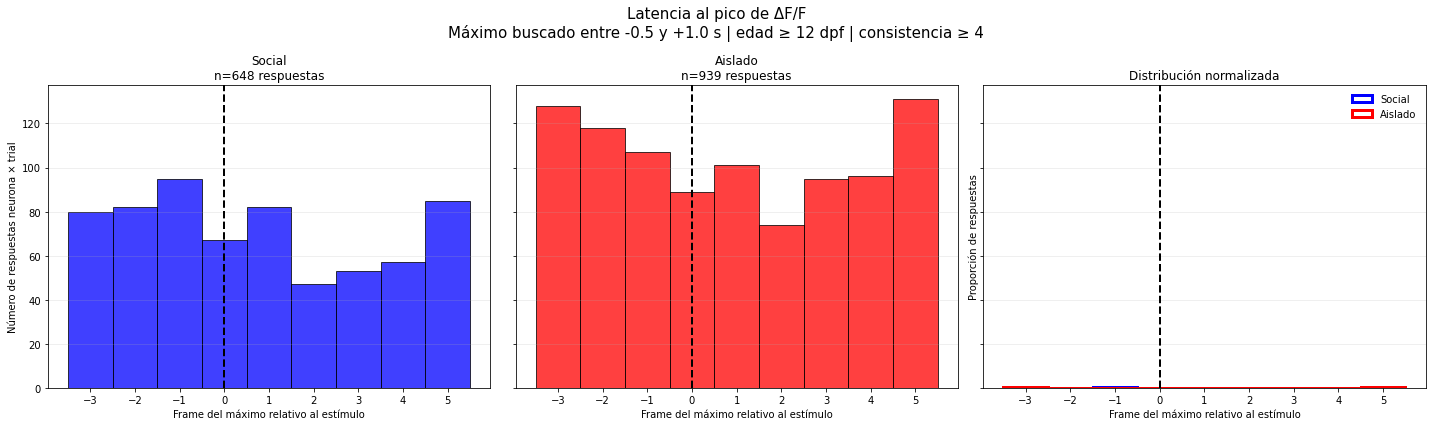

In [69]:
# ================================================================
# LATENCIA AL PICO DE ΔF/F
#
# Cada observación = una neurona en un trial AV donde respondió
#
# Para cada neurona × trial:
#   1. buscar máximo ΔF/F entre -0.5 y +1.0 s
#   2. guardar el frame relativo al estímulo donde ocurre
#
# PANEL 1 = Social
# PANEL 2 = Aislado
# PANEL 3 = histogramas superpuestos
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ================================================================
# CONFIGURACIÓN
# ================================================================

latencia_inicio = -.5
latencia_fin = 1


# ================================================================
# RESULTADOS
# ================================================================

filas_latencia = []


# ================================================================
# RECORRER PECES
# ================================================================

for fish_id, area in areas.items():

    aislado = getattr(
        area,
        "aislado",
        None
    )

    edad = getattr(
        area,
        "edad",
        np.nan
    )


    # ------------------------------------------------------------
    # FILTROS
    # ------------------------------------------------------------

    if (
        edad is None or
        not np.isfinite(edad) or
        edad < edad_minima
    ):
        continue

    if aislado not in [0, 1]:
        continue


    condicion = (
        "Social"
        if aislado == 0
        else "Aislado"
    )


    # ============================================================
    # NEURONAS CONSISTENTES
    # ============================================================

    active_mask = get_consistent_mask_original(
        area
    )

    if (
        active_mask is None or
        not active_mask.any()
    ):
        continue


    consistent_indices = np.where(
        active_mask
    )[0]


    # ============================================================
    # RECORRER TRIALS AV
    # ============================================================

    av_trial_n = 0

    for tr in getattr(
        area,
        "trials_rea",
        []
    ):

        if _get_condition(tr) != "AV":
            continue

        av_trial_n += 1


        # ========================================================
        # ACTIVIDAD BINARIA
        #
        # Sólo para determinar si la neurona respondió
        # ========================================================

        rb = getattr(
            tr,
            "roi_binaries_rea",
            None
        )

        if (
            rb is None or
            region_key not in rb
        ):
            continue


        B = (
            np.asarray(
                rb[region_key]
            ) > 0
        ).astype(int)


        # ========================================================
        # ΔF/F
        #
        # Para encontrar el pico
        # ========================================================

        rdff = getattr(
            tr,
            "roi_dffs_rea",
            None
        )

        if (
            rdff is None or
            region_key not in rdff
        ):
            continue


        D = np.asarray(
            rdff[region_key],
            dtype=float
        )


        # ========================================================
        # COMPROBACIONES
        # ========================================================

        if len(active_mask) != B.shape[0]:
            continue

        if D.shape[0] != B.shape[0]:
            continue


        # ========================================================
        # TIEMPO
        # ========================================================

        t, tr_fps = _trial_timebase(
            tr,
            fps
        )


        n_frames = min(
            B.shape[1],
            D.shape[1],
            len(t)
        )


        B = B[:, :n_frames]
        D = D[:, :n_frames]
        t = t[:n_frames]


        # ========================================================
        # FRAME DEL ESTÍMULO
        # ========================================================

        stim_frame = int(
            round(
                stim_s * tr_fps
            )
        )


        # ========================================================
        # VENTANA ORIGINAL DE RESPUESTA
        #
        # Igual que en tu análisis anterior:
        # determina si ESA neurona respondió en ESTE trial
        # ========================================================

        win_idx = np.arange(
            stim_frame - frames_pre,
            stim_frame + frames_post + 1
        )


        win_idx = win_idx[
            (win_idx >= 0) &
            (win_idx < n_frames)
        ]


        if len(win_idx) == 0:
            continue


        # ========================================================
        # VENTANA PARA BUSCAR EL PICO
        #
        # -0.5 s → +1.0 s
        # ========================================================

        t_rel = t - stim_s


        peak_idx = np.where(
            (t_rel >= latencia_inicio) &
            (t_rel <= latencia_fin)
        )[0]


        if len(peak_idx) == 0:
            continue


        # ========================================================
        # RECORRER NEURONAS
        # ========================================================

        for neuron_idx in consistent_indices:


            # ----------------------------------------------------
            # Sólo neuronas que respondieron en ESTE trial
            # ----------------------------------------------------

            if (
                B[
                    neuron_idx,
                    win_idx
                ].sum()
                == 0
            ):
                continue


            # ====================================================
            # ΔF/F EN VENTANA DEL PICO
            # ====================================================

            dff_ventana = D[
                neuron_idx,
                peak_idx
            ]


            # ----------------------------------------------------
            # Evitar curva completamente NaN
            # ----------------------------------------------------

            if not np.isfinite(
                dff_ventana
            ).any():
                continue


            # ====================================================
            # BUSCAR MÁXIMO
            # ====================================================

            pos_max = np.nanargmax(
                dff_ventana
            )


            # Frame absoluto donde ocurrió el máximo
            frame_max = peak_idx[
                pos_max
            ]


            # ====================================================
            # FRAME RELATIVO AL ESTÍMULO
            #
            # 0  = frame del estímulo
            # -1 = un frame antes
            # +1 = un frame después
            # ====================================================

            frame_relativo = (
                frame_max -
                stim_frame
            )


            # Tiempo exacto relativo
            tiempo_pico = t_rel[
                frame_max
            ]


            # Valor máximo ΔF/F
            valor_pico = D[
                neuron_idx,
                frame_max
            ]


            # ====================================================
            # GUARDAR
            # ====================================================

            filas_latencia.append({

                "fish_id": fish_id,

                "edad": edad,

                "condicion": condicion,

                "neuron": neuron_idx,

                "trial": av_trial_n,

                "frame_pico": frame_relativo,

                "tiempo_pico": tiempo_pico,

                "dff_pico": valor_pico
            })


# ================================================================
# DATAFRAME
# ================================================================

df_latencia_pico = pd.DataFrame(
    filas_latencia
)


print(
    "Número total de respuestas:",
    len(df_latencia_pico)
)

print("\nPor condición:")

print(
    df_latencia_pico
    .groupby("condicion")
    .size()
)


display(
    df_latencia_pico.head()
)


# ================================================================
# EXTRAER FRAMES
# ================================================================

frames_social = (
    df_latencia_pico.loc[
        df_latencia_pico["condicion"] == "Social",
        "frame_pico"
    ]
    .dropna()
    .astype(int)
    .values
)


frames_aislado = (
    df_latencia_pico.loc[
        df_latencia_pico["condicion"] == "Aislado",
        "frame_pico"
    ]
    .dropna()
    .astype(int)
    .values
)


# ================================================================
# BINS
#
# Un bin exactamente por cada frame
# ================================================================

frame_min = int(
    df_latencia_pico["frame_pico"].min()
)

frame_max = int(
    df_latencia_pico["frame_pico"].max()
)


frames_posibles = np.arange(
    frame_min,
    frame_max + 1
)


bins = np.arange(
    frame_min - 0.5,
    frame_max + 1.5,
    1
)


# ================================================================
# FIGURA
# ================================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
    sharey=True
)


# ================================================================
# PANEL 1 — SOCIAL
# ================================================================

ax = axes[0]


ax.hist(
    frames_social,
    bins=bins,
    color="blue",
    alpha=0.75,
    edgecolor="black"
)


ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Estímulo"
)


ax.set_xticks(
    frames_posibles
)


ax.set_xlabel(
    "Frame del máximo relativo al estímulo"
)

ax.set_ylabel(
    "Número de respuestas neurona × trial"
)


ax.set_title(
    f"Social\n"
    f"n={len(frames_social)} respuestas"
)


ax.grid(
    axis="y",
    alpha=0.25
)


# ================================================================
# PANEL 2 — AISLADO
# ================================================================

ax = axes[1]


ax.hist(
    frames_aislado,
    bins=bins,
    color="red",
    alpha=0.75,
    edgecolor="black"
)


ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Estímulo"
)


ax.set_xticks(
    frames_posibles
)


ax.set_xlabel(
    "Frame del máximo relativo al estímulo"
)


ax.set_title(
    f"Aislado\n"
    f"n={len(frames_aislado)} respuestas"
)


ax.grid(
    axis="y",
    alpha=0.25
)


# ================================================================
# PANEL 3 — SUPERPUESTOS
#
# Uso densidad/proporción para poder comparar aunque haya
# diferente cantidad de respuestas en cada condición
# ================================================================

ax = axes[2]


# ------------------------------------------------
# Convertimos a proporción por condición
# ------------------------------------------------

pesos_social = np.ones(
    len(frames_social)
) / len(frames_social)


pesos_aislado = np.ones(
    len(frames_aislado)
) / len(frames_aislado)


ax.hist(
    frames_social,
    bins=bins,
    weights=pesos_social,
    histtype="step",
    color="blue",
    linewidth=3,
    label="Social"
)


ax.hist(
    frames_aislado,
    bins=bins,
    weights=pesos_aislado,
    histtype="step",
    color="red",
    linewidth=3,
    label="Aislado"
)


ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2
)


ax.set_xticks(
    frames_posibles
)


ax.set_xlabel(
    "Frame del máximo relativo al estímulo"
)

ax.set_ylabel(
    "Proporción de respuestas"
)


ax.set_title(
    "Distribución normalizada"
)


ax.legend(
    frameon=False
)


ax.grid(
    axis="y",
    alpha=0.25
)


# ================================================================
# TÍTULO GENERAL
# ================================================================

fig.suptitle(
    f"Latencia al pico de ΔF/F\n"
    f"Máximo buscado entre "
    f"{latencia_inicio:.1f} y +{latencia_fin:.1f} s | "
    f"edad ≥ {edad_minima} dpf | "
    f"consistencia ≥ {consistencia_repeticion}",
    fontsize=15
)


plt.tight_layout()
plt.show()

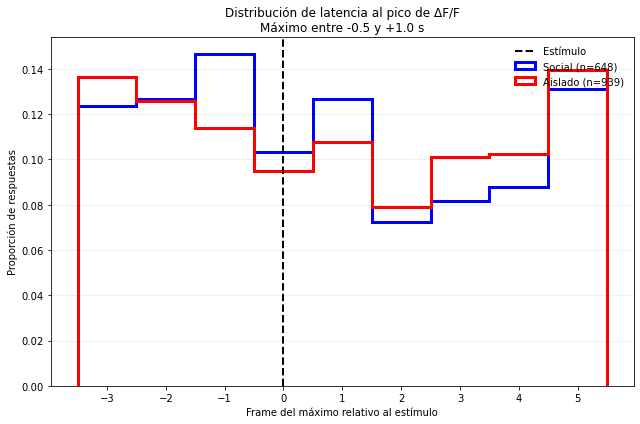

In [70]:
# ================================================================
# FIGURA APARTE — DISTRIBUCIÓN NORMALIZADA DE LATENCIA AL PICO
# ================================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)


# ================================================================
# PESOS → PROPORCIÓN DENTRO DE CADA CONDICIÓN
# ================================================================

pesos_social = (
    np.ones(len(frames_social))
    / len(frames_social)
)

pesos_aislado = (
    np.ones(len(frames_aislado))
    / len(frames_aislado)
)


# ================================================================
# SOCIAL
# ================================================================

ax.hist(
    frames_social,
    bins=bins,
    weights=pesos_social,
    histtype="step",
    color="blue",
    linewidth=3,
    label=f"Social (n={len(frames_social)})"
)


# ================================================================
# AISLADO
# ================================================================

ax.hist(
    frames_aislado,
    bins=bins,
    weights=pesos_aislado,
    histtype="step",
    color="red",
    linewidth=3,
    label=f"Aislado (n={len(frames_aislado)})"
)


# ================================================================
# FRAME DEL ESTÍMULO
# ================================================================

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Estímulo"
)


# ================================================================
# EJES
# ================================================================

ax.set_xticks(
    frames_posibles
)

ax.set_xlabel(
    "Frame del máximo relativo al estímulo"
)

ax.set_ylabel(
    "Proporción de respuestas"
)

ax.set_title(
    "Distribución de latencia al pico de ΔF/F\n"
    f"Máximo entre {latencia_inicio:.1f} y +{latencia_fin:.1f} s"
)

ax.legend(
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()
plt.show()

Número total de neuronas: 344

Neuronas por condición:
condicion
Aislado    204
Social     140
dtype: int64


,fish_id,edad,condicion,neuron,n_trials,frame_pico,tiempo_pico,dff_pico
0,148-1,12.0,Social,6,5,-2,-0.24,0.260686
1,148-1,12.0,Social,118,4,-2,-0.24,0.330408
2,148-1,12.0,Social,130,4,-3,-0.40,0.181941
3,149-1,12.0,Aislado,3,5,0,0.08,0.608264
4,149-1,12.0,Aislado,5,5,0,0.08,0.421890


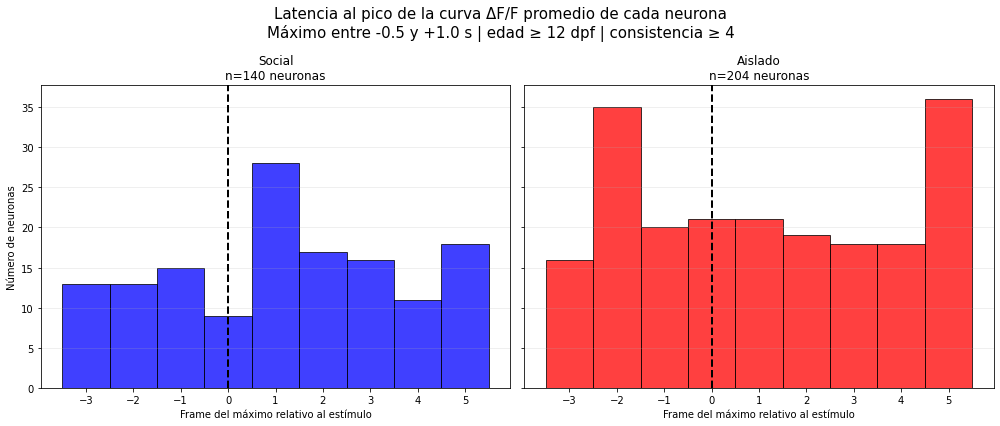

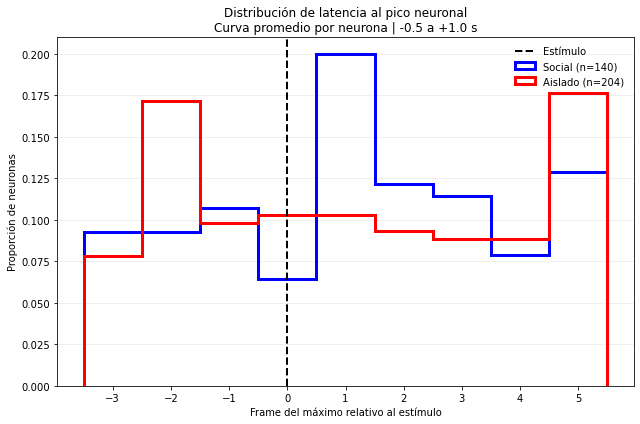

In [71]:
# ================================================================
# LATENCIA AL PICO — CURVA PROMEDIO POR NEURONA
#
# Cada observación = UNA neurona
#
# Para cada neurona consistente:
#   1. tomar trials AV donde respondió
#   2. promediar ΔF/F entre esos trials
#   3. buscar el máximo de esa curva promedio entre -0.5 y +1.0 s
#   4. guardar el frame relativo al estímulo donde ocurre
#
# FIGURA 1:
#   Panel 1 = Social
#   Panel 2 = Aislado
#
# FIGURA 2:
#   Distribuciones normalizadas superpuestas
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ================================================================
# CONFIGURACIÓN
# ================================================================

latencia_inicio = -.5
latencia_fin = 1


# ================================================================
# RESULTADOS
# ================================================================

filas_latencia_neurona = []


# ================================================================
# RECORRER PECES
# ================================================================

for fish_id, area in areas.items():

    aislado = getattr(area, "aislado", None)
    edad = getattr(area, "edad", np.nan)


    # ------------------------------------------------------------
    # FILTROS
    # ------------------------------------------------------------

    if (
        edad is None or
        not np.isfinite(edad) or
        edad < edad_minima
    ):
        continue

    if aislado not in [0, 1]:
        continue


    condicion = (
        "Social"
        if aislado == 0
        else "Aislado"
    )


    # ============================================================
    # NEURONAS CONSISTENTES
    # ============================================================

    active_mask = get_consistent_mask_original(area)

    if (
        active_mask is None or
        not active_mask.any()
    ):
        continue


    consistent_indices = np.where(
        active_mask
    )[0]


    # ============================================================
    # GUARDAR TRIALS AV RESPONDIDOS DE CADA NEURONA
    # ============================================================

    perfiles_por_neurona = {
        n: []
        for n in consistent_indices
    }

    tiempos_por_neurona = {
        n: []
        for n in consistent_indices
    }


    # ============================================================
    # RECORRER TRIALS AV
    # ============================================================

    for tr in getattr(area, "trials_rea", []):

        if _get_condition(tr) != "AV":
            continue


        # ========================================================
        # ACTIVIDAD BINARIA
        # ========================================================

        rb = getattr(
            tr,
            "roi_binaries_rea",
            None
        )

        if (
            rb is None or
            region_key not in rb
        ):
            continue


        B = (
            np.asarray(
                rb[region_key]
            ) > 0
        ).astype(int)


        # ========================================================
        # ΔF/F
        # ========================================================

        rdff = getattr(
            tr,
            "roi_dffs_rea",
            None
        )

        if (
            rdff is None or
            region_key not in rdff
        ):
            continue


        D = np.asarray(
            rdff[region_key],
            dtype=float
        )


        # ========================================================
        # COMPROBACIONES
        # ========================================================

        if len(active_mask) != B.shape[0]:
            continue

        if D.shape[0] != B.shape[0]:
            continue


        # ========================================================
        # TIEMPO
        # ========================================================

        t, tr_fps = _trial_timebase(
            tr,
            fps
        )


        n_frames = min(
            B.shape[1],
            D.shape[1],
            len(t)
        )


        B = B[:, :n_frames]
        D = D[:, :n_frames]
        t = t[:n_frames]

        t_rel = t - stim_s


        stim_frame = int(
            round(
                stim_s * tr_fps
            )
        )


        # ========================================================
        # VENTANA ORIGINAL DE RESPUESTA
        #
        # Determina si la neurona respondió en ESTE trial
        # ========================================================

        win_idx = np.arange(
            stim_frame - frames_pre,
            stim_frame + frames_post + 1
        )


        win_idx = win_idx[
            (win_idx >= 0) &
            (win_idx < n_frames)
        ]


        if len(win_idx) == 0:
            continue


        # ========================================================
        # VENTANA DE LATENCIA
        #
        # Guardamos solamente -0.5 a +1 s
        # ========================================================

        peak_mask = (
            (t_rel >= latencia_inicio) &
            (t_rel <= latencia_fin)
        )


        if peak_mask.sum() < 2:
            continue


        t_peak = t_rel[
            peak_mask
        ]


        # ========================================================
        # RECORRER NEURONAS
        # ========================================================

        for neuron_idx in consistent_indices:


            # ----------------------------------------------------
            # Sólo si respondió en este AV
            # ----------------------------------------------------

            if (
                B[
                    neuron_idx,
                    win_idx
                ].sum()
                == 0
            ):
                continue


            perfil = D[
                neuron_idx,
                peak_mask
            ]


            if not np.isfinite(perfil).any():
                continue


            perfiles_por_neurona[
                neuron_idx
            ].append(
                perfil
            )


            tiempos_por_neurona[
                neuron_idx
            ].append(
                t_peak
            )


    # ============================================================
    # UNA CURVA PROMEDIO POR NEURONA
    # ============================================================

    for neuron_idx in consistent_indices:

        perfiles = perfiles_por_neurona[
            neuron_idx
        ]

        tiempos = tiempos_por_neurona[
            neuron_idx
        ]


        if len(perfiles) == 0:
            continue


        # --------------------------------------------------------
        # Igualar longitud
        # --------------------------------------------------------

        min_len = min(
            len(p)
            for p in perfiles
        )


        perfiles_array = np.vstack([
            p[:min_len]
            for p in perfiles
        ])


        t_neurona = tiempos[
            0
        ][:min_len]


        # ========================================================
        # PROMEDIO DE LOS TRIALS DE ESTA NEURONA
        # ========================================================

        curva_promedio = np.nanmean(
            perfiles_array,
            axis=0
        )


        # ========================================================
        # BUSCAR MÁXIMO DE LA CURVA PROMEDIO
        # ========================================================

        if not np.isfinite(
            curva_promedio
        ).any():
            continue


        pos_max = np.nanargmax(
            curva_promedio
        )


        # ========================================================
        # FRAME RELATIVO
        #
        # Como usamos t_neurona, convertimos la posición temporal
        # a frames usando el fps nominal.
        #
        # 0  = estímulo
        # -1 = frame anterior
        # +1 = frame posterior
        # ========================================================

        tiempo_pico = t_neurona[
            pos_max
        ]


        frame_pico = int(
            round(
                tiempo_pico * fps
            )
        )


        valor_pico = curva_promedio[
            pos_max
        ]


        # ========================================================
        # GUARDAR
        # ========================================================

        filas_latencia_neurona.append({

            "fish_id": fish_id,

            "edad": edad,

            "condicion": condicion,

            "neuron": neuron_idx,

            "n_trials": len(perfiles),

            "frame_pico": frame_pico,

            "tiempo_pico": tiempo_pico,

            "dff_pico": valor_pico
        })


# ================================================================
# DATAFRAME
# ================================================================

df_latencia_neurona = pd.DataFrame(
    filas_latencia_neurona
)


print(
    "Número total de neuronas:",
    len(df_latencia_neurona)
)


print("\nNeuronas por condición:")

print(
    df_latencia_neurona
    .groupby("condicion")
    .size()
)


display(
    df_latencia_neurona.head()
)


# ================================================================
# EXTRAER FRAMES
# ================================================================

frames_social_neurona = (
    df_latencia_neurona.loc[
        df_latencia_neurona["condicion"] == "Social",
        "frame_pico"
    ]
    .dropna()
    .astype(int)
    .values
)


frames_aislado_neurona = (
    df_latencia_neurona.loc[
        df_latencia_neurona["condicion"] == "Aislado",
        "frame_pico"
    ]
    .dropna()
    .astype(int)
    .values
)


# ================================================================
# BINS — UNO POR FRAME
# ================================================================

frame_min = int(
    df_latencia_neurona["frame_pico"].min()
)

frame_max = int(
    df_latencia_neurona["frame_pico"].max()
)


frames_posibles_neurona = np.arange(
    frame_min,
    frame_max + 1
)


bins_neurona = np.arange(
    frame_min - 0.5,
    frame_max + 1.5,
    1
)


# ================================================================
# FIGURA 1 — HISTOGRAMAS SEPARADOS
# ================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    sharey=True
)


# ================================================================
# SOCIAL
# ================================================================

ax = axes[0]


ax.hist(
    frames_social_neurona,
    bins=bins_neurona,
    color="blue",
    alpha=0.75,
    edgecolor="black"
)


ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2
)


ax.set_xticks(
    frames_posibles_neurona
)


ax.set_xlabel(
    "Frame del máximo relativo al estímulo"
)

ax.set_ylabel(
    "Número de neuronas"
)


ax.set_title(
    f"Social\n"
    f"n={len(frames_social_neurona)} neuronas"
)


ax.grid(
    axis="y",
    alpha=0.25
)


# ================================================================
# AISLADO
# ================================================================

ax = axes[1]


ax.hist(
    frames_aislado_neurona,
    bins=bins_neurona,
    color="red",
    alpha=0.75,
    edgecolor="black"
)


ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2
)


ax.set_xticks(
    frames_posibles_neurona
)


ax.set_xlabel(
    "Frame del máximo relativo al estímulo"
)


ax.set_title(
    f"Aislado\n"
    f"n={len(frames_aislado_neurona)} neuronas"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.suptitle(
    f"Latencia al pico de la curva ΔF/F promedio de cada neurona\n"
    f"Máximo entre {latencia_inicio:.1f} y +{latencia_fin:.1f} s | "
    f"edad ≥ {edad_minima} dpf | "
    f"consistencia ≥ {consistencia_repeticion}",
    fontsize=15
)


plt.tight_layout()
plt.show()


# ================================================================
# FIGURA 2 — DISTRIBUCIONES NORMALIZADAS SUPERPUESTAS
# ================================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)


# ================================================================
# PESOS → PROPORCIÓN DENTRO DE CADA CONDICIÓN
# ================================================================

pesos_social = (
    np.ones(
        len(frames_social_neurona)
    )
    / len(frames_social_neurona)
)


pesos_aislado = (
    np.ones(
        len(frames_aislado_neurona)
    )
    / len(frames_aislado_neurona)
)


# ================================================================
# SOCIAL
# ================================================================

ax.hist(
    frames_social_neurona,
    bins=bins_neurona,
    weights=pesos_social,
    histtype="step",
    color="blue",
    linewidth=3,
    label=(
        f"Social "
        f"(n={len(frames_social_neurona)})"
    )
)


# ================================================================
# AISLADO
# ================================================================

ax.hist(
    frames_aislado_neurona,
    bins=bins_neurona,
    weights=pesos_aislado,
    histtype="step",
    color="red",
    linewidth=3,
    label=(
        f"Aislado "
        f"(n={len(frames_aislado_neurona)})"
    )
)


# ================================================================
# ESTÍMULO
# ================================================================

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Estímulo"
)


# ================================================================
# EJES
# ================================================================

ax.set_xticks(
    frames_posibles_neurona
)


ax.set_xlabel(
    "Frame del máximo relativo al estímulo"
)

ax.set_ylabel(
    "Proporción de neuronas"
)


ax.set_title(
    "Distribución de latencia al pico neuronal\n"
    f"Curva promedio por neurona | "
    f"{latencia_inicio:.1f} a +{latencia_fin:.1f} s"
)


ax.legend(
    frameon=False
)


ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()
plt.show()

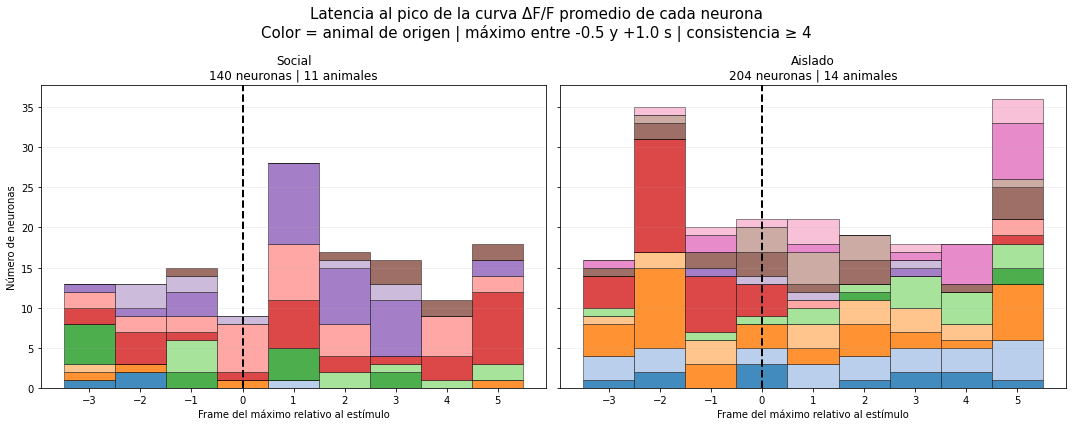

In [72]:
# ================================================================
# FIGURA 1 — HISTOGRAMAS POR CONDICIÓN
# BARRAS APILADAS SEGÚN ANIMAL
#
# Cada color = un animal distinto
# No se muestra leyenda de fish_id
# ================================================================

import matplotlib.pyplot as plt
import numpy as np


fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
    sharey=True
)


# ================================================================
# FUNCIÓN PARA GRAFICAR UNA CONDICIÓN
# ================================================================

def histograma_por_animal(
    ax,
    condicion,
    color_base
):

    df_cond = (
        df_latencia_neurona[
            df_latencia_neurona["condicion"] == condicion
        ]
        .copy()
    )


    # ------------------------------------------------------------
    # Animales presentes
    # ------------------------------------------------------------

    fish_ids = sorted(
        df_cond["fish_id"].unique()
    )


    # ------------------------------------------------------------
    # Un array de frames por animal
    #
    # Cada array será una capa del histograma apilado
    # ------------------------------------------------------------

    datos_por_pez = []

    for fish_id in fish_ids:

        frames_pez = (
            df_cond.loc[
                df_cond["fish_id"] == fish_id,
                "frame_pico"
            ]
            .dropna()
            .astype(int)
            .values
        )

        datos_por_pez.append(
            frames_pez
        )


    # ============================================================
    # COLORES
    #
    # Un color distinto para cada animal
    # ============================================================

    cmap = plt.get_cmap(
        "tab20"
    )

    colores_peces = [
        cmap(i % 20)
        for i in range(len(fish_ids))
    ]


    # ============================================================
    # HISTOGRAMA APILADO
    # ============================================================

    ax.hist(
        datos_por_pez,
        bins=bins_neurona,
        stacked=True,
        color=colores_peces,
        edgecolor="black",
        linewidth=0.5,
        alpha=0.85
    )


    # ============================================================
    # ESTÍMULO
    # ============================================================

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=2
    )


    # ============================================================
    # EJES
    # ============================================================

    ax.set_xticks(
        frames_posibles_neurona
    )

    ax.set_xlabel(
        "Frame del máximo relativo al estímulo"
    )

    ax.set_title(
        f"{condicion}\n"
        f"{len(df_cond)} neuronas | "
        f"{len(fish_ids)} animales"
    )

    ax.grid(
        axis="y",
        alpha=0.20
    )


# ================================================================
# PANEL SOCIAL
# ================================================================

histograma_por_animal(
    axes[0],
    "Social",
    "blue"
)

axes[0].set_ylabel(
    "Número de neuronas"
)


# ================================================================
# PANEL AISLADO
# ================================================================

histograma_por_animal(
    axes[1],
    "Aislado",
    "red"
)


# ================================================================
# TÍTULO GENERAL
# ================================================================

fig.suptitle(
    f"Latencia al pico de la curva ΔF/F promedio de cada neurona\n"
    f"Color = animal de origen | "
    f"máximo entre {latencia_inicio:.1f} y +{latencia_fin:.1f} s | "
    f"consistencia ≥ {consistencia_repeticion}",
    fontsize=15
)


plt.tight_layout()
plt.show()